#CV - HW 2 - Hupalo Andrii report

##Part 1 DDPM & DDIM

Finally got my 3090 back (took about a month in service to repair)

Just after I wrote that line, light went off

### First run
On my first run I used basic UNetMNIST with simple convolutional layers (Conv2d/ConvTranspose2d) and a small (64) time embedding dimension.

Code snippet and output:

```
model = UNetMNIST(time_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("🚀 Starting training...")

for epoch in range(epochs):
    for step, (batch, _) in enumerate(train_loader):
        optimizer.zero_grad()

        batch = batch.to(device)
        t = torch.randint(0, TIMESTEPS, (batch.shape[0],), device=device).long()

        x_noisy, noise = forward_diffusion_sample(batch, t, device)

        # Use 64 here to match the new model definition
        t_emb = get_time_embedding(t, embedding_dim=64)

        predicted_noise = model(x_noisy, t_emb)

        loss = F.mse_loss(noise, predicted_noise)
        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print(f"Epoch {epoch} | Step {step:03d} | Loss: {loss.item():.4f}")
```

<pre>
Epoch 0 | Step 000 | Loss: 0.9319
Epoch 0 | Step 100 | Loss: 0.2154
Epoch 0 | Step 200 | Loss: 0.1724
Epoch 0 | Step 300 | Loss: 0.1255
Epoch 0 | Step 400 | Loss: 0.0975
Epoch 1 | Step 000 | Loss: 0.0704
Epoch 1 | Step 100 | Loss: 0.0654
Epoch 1 | Step 200 | Loss: 0.0742
Epoch 1 | Step 300 | Loss: 0.0573
Epoch 1 | Step 400 | Loss: 0.0912
Epoch 2 | Step 000 | Loss: 0.0734
Epoch 2 | Step 100 | Loss: 0.0595
Epoch 2 | Step 200 | Loss: 0.0671
Epoch 2 | Step 300 | Loss: 0.0476
Epoch 2 | Step 400 | Loss: 0.0488
Epoch 3 | Step 000 | Loss: 0.0585
Epoch 3 | Step 100 | Loss: 0.0524
Epoch 3 | Step 200 | Loss: 0.0557
Epoch 3 | Step 300 | Loss: 0.0700
Epoch 3 | Step 400 | Loss: 0.0498
Epoch 4 | Step 000 | Loss: 0.0432
Epoch 4 | Step 100 | Loss: 0.0562
Epoch 4 | Step 200 | Loss: 0.0461
Epoch 4 | Step 300 | Loss: 0.0366
Epoch 4 | Step 400 | Loss: 0.0522
Epoch 5 | Step 000 | Loss: 0.0357
Epoch 5 | Step 100 | Loss: 0.0469
Epoch 5 | Step 200 | Loss: 0.0395
Epoch 5 | Step 300 | Loss: 0.0381
Epoch 5 | Step 400 | Loss: 0.0465
Epoch 6 | Step 000 | Loss: 0.0482
Epoch 6 | Step 100 | Loss: 0.0449
Epoch 6 | Step 200 | Loss: 0.0361
Epoch 6 | Step 300 | Loss: 0.0383
Epoch 6 | Step 400 | Loss: 0.0336
Epoch 7 | Step 000 | Loss: 0.0428
Epoch 7 | Step 100 | Loss: 0.0469
Epoch 7 | Step 200 | Loss: 0.0353
Epoch 7 | Step 300 | Loss: 0.0401
Epoch 7 | Step 400 | Loss: 0.0424
Epoch 8 | Step 000 | Loss: 0.0325
Epoch 8 | Step 100 | Loss: 0.0432
Epoch 8 | Step 200 | Loss: 0.0551
Epoch 8 | Step 300 | Loss: 0.0439
Epoch 8 | Step 400 | Loss: 0.0406
Epoch 9 | Step 000 | Loss: 0.0348
Epoch 9 | Step 100 | Loss: 0.0303
Epoch 9 | Step 200 | Loss: 0.0371
Epoch 9 | Step 300 | Loss: 0.0387
Epoch 9 | Step 400 | Loss: 0.0482
</pre>

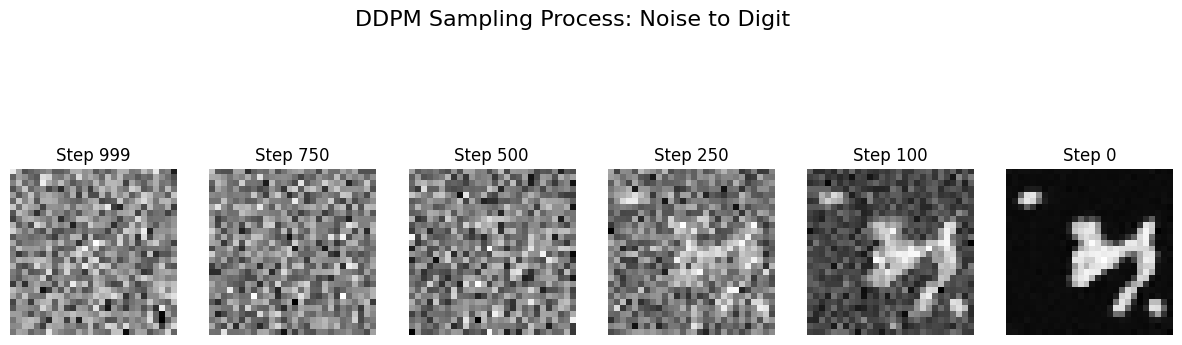

Loss goes back and forth, 0.0482 is not bad but not perfect either. We got pretty poor result with distinguishable blob. Probably '4'?

###Second run

I moved from a standard CNN U-Net to a time - conditioned Residual U-Net.

Configuration (Used pixel-space training on the MNIST dataset. Meaning model learns to denoise the actual raw pixels of the image directly. In our case 28 x 28):

```
# Training configuration
BATCH_SIZE = 128       # How many images to process at once
EPOCHS = 20            # Number of training epochs
LOG_INTERVAL = 100     # How often to print progress updates

# Model architecture
IMAGE_SIZE = 28        # MNIST image size (28x28)
IMAGE_CHANNELS = 1     # Grayscale images (1 channel)
HIDDEN_DIM = 128       # Base hidden dimension for UNet
TIMESTEPS = 1000       # Number of diffusion timesteps for DDPM

# DDIM configuration
DDIM_STEPS = 50        # Number of steps for DDIM sampling (much faster!)

# Diffusion-specific hyperparameters
LR = 2e-4              # Learning rate
BETA_START = 1e-4      # Starting noise level
BETA_END = 0.02        # Ending noise level

```

Normalization:
```
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])
```

Residual connections are to keep the image structure + injected time embeddings inside every Residual block (to understand the noise level). Snippet:

```
class ResidualBlock(nn.Module):
    """
    Residual block with time embedding.
    """

    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU()
        )

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU()
        )

        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x, t):
        h = self.conv1(x)

        # Add time embedding
        time_emb = self.time_mlp(t)
        h = h + time_emb[:, :, None, None]

        h = self.conv2(h)

        return h + self.residual_conv(x)

```

DDPM

Epoch 2:

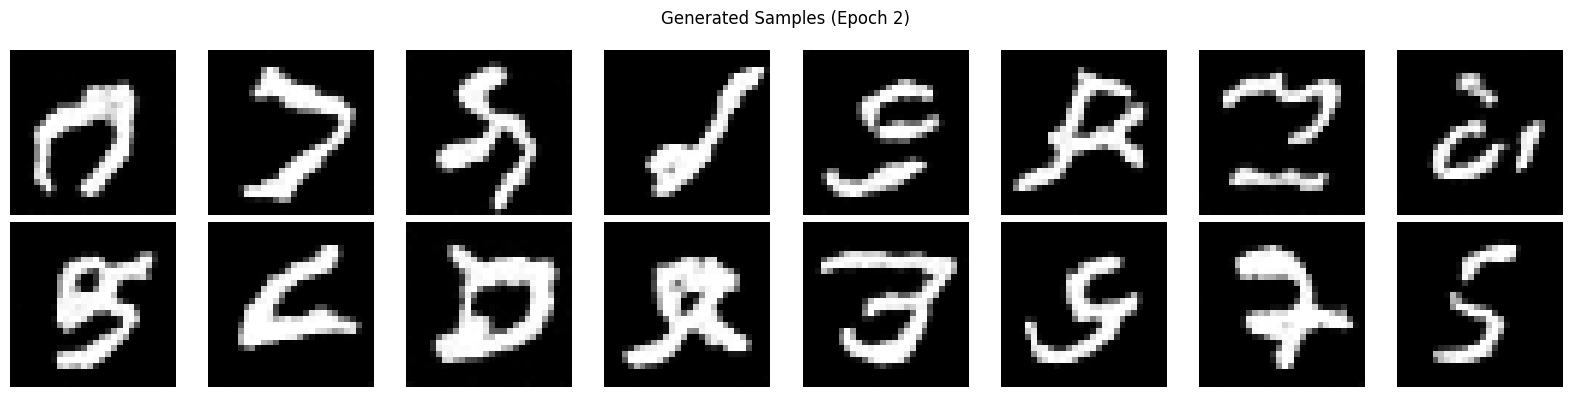

Epoch 20:


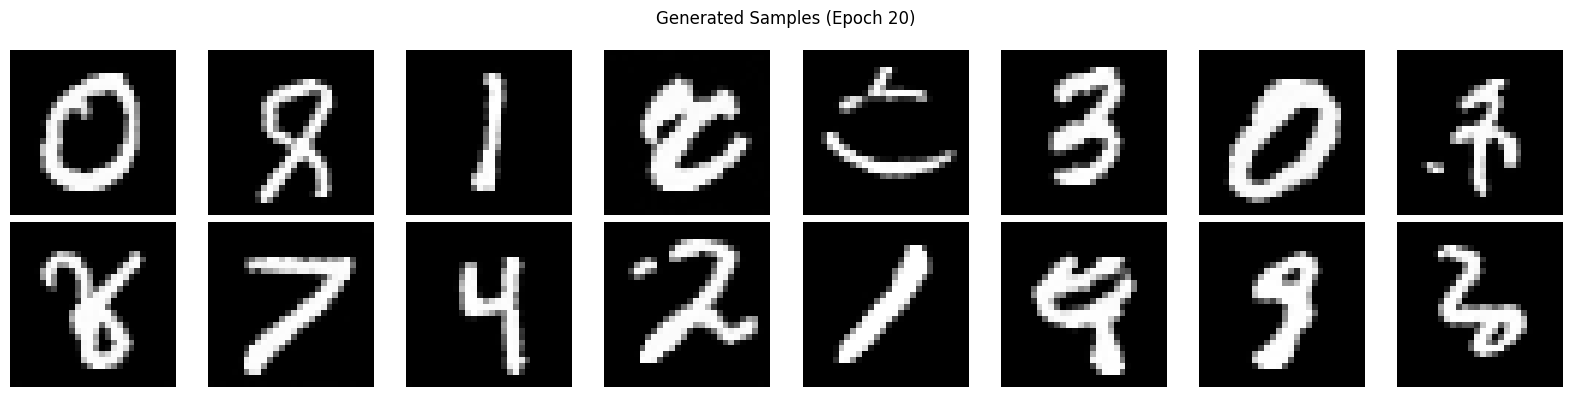

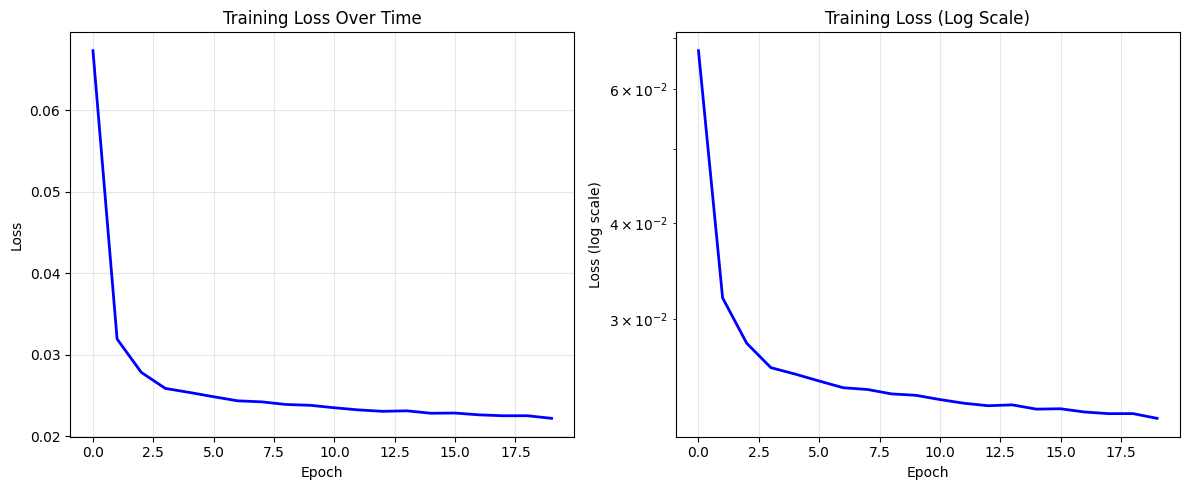

   Initial loss: 0.067286

   Final and best loss: 0.022219 (epoch 20)
   
   Loss reduction: 67.0%

Loss and training looks good. Improvement is obvious. Not all numbers are recognizable though.

DDPM denoising (1000 timmestep):

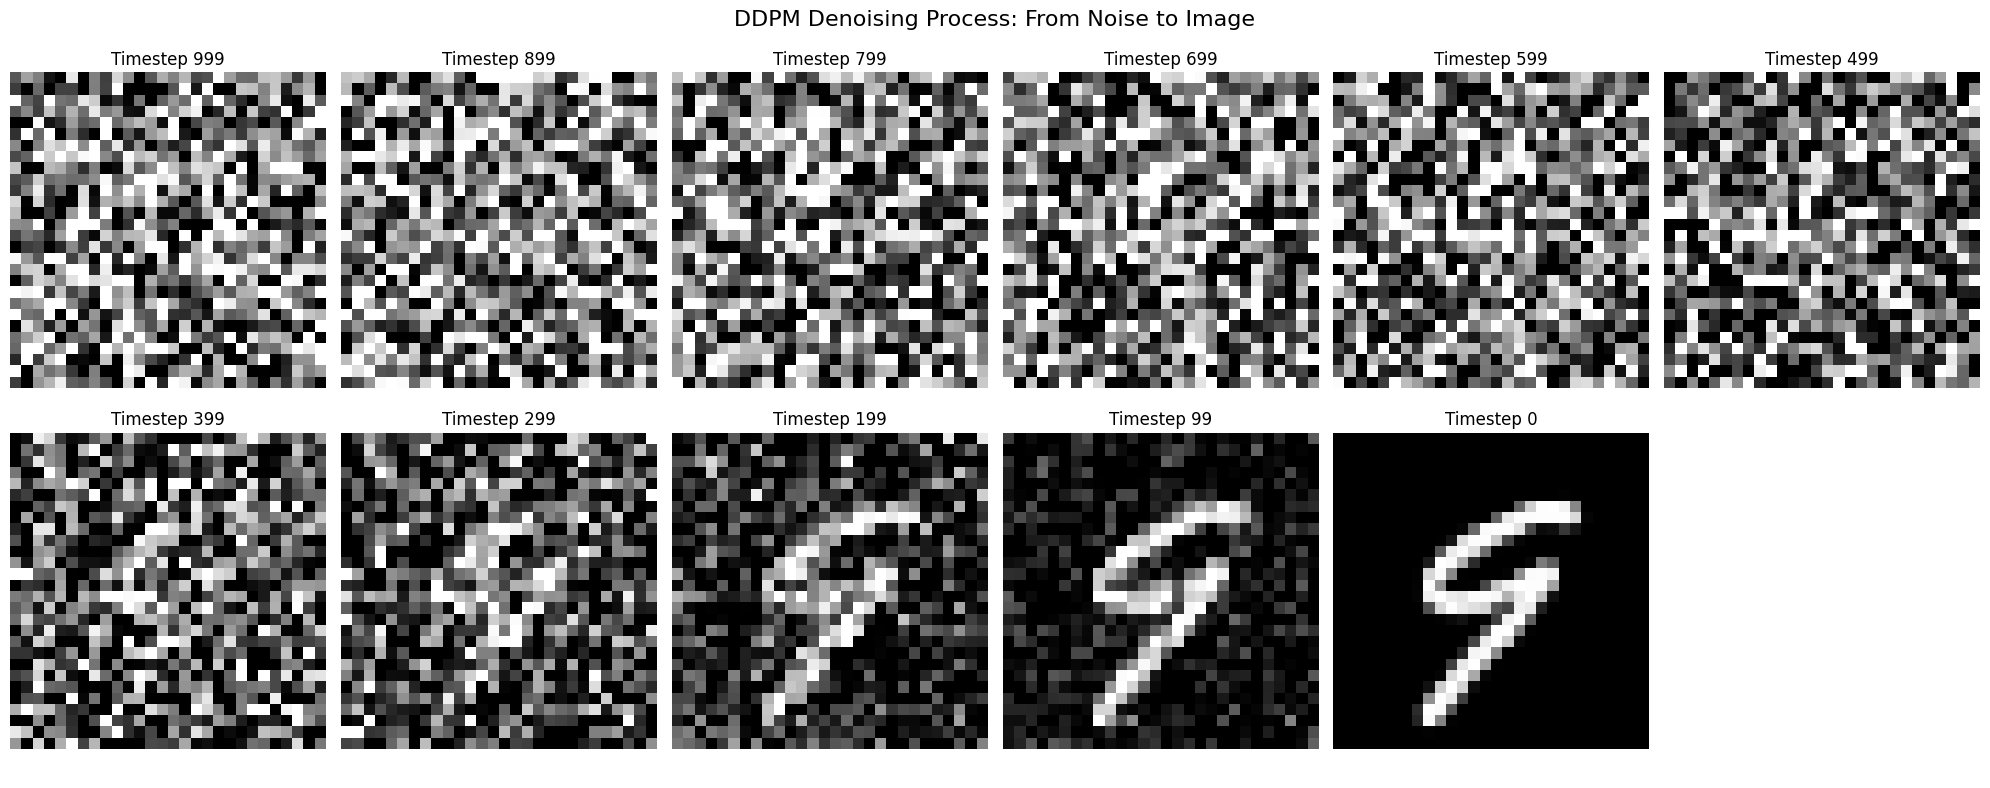

Telling to model what time it is worked pretty well:

We see a noisy image at step 900 (almost pure static) up to timestep 0 (almost clear). It is probably 9. But there is a small chance of number being 4.

64 DDPM samples:


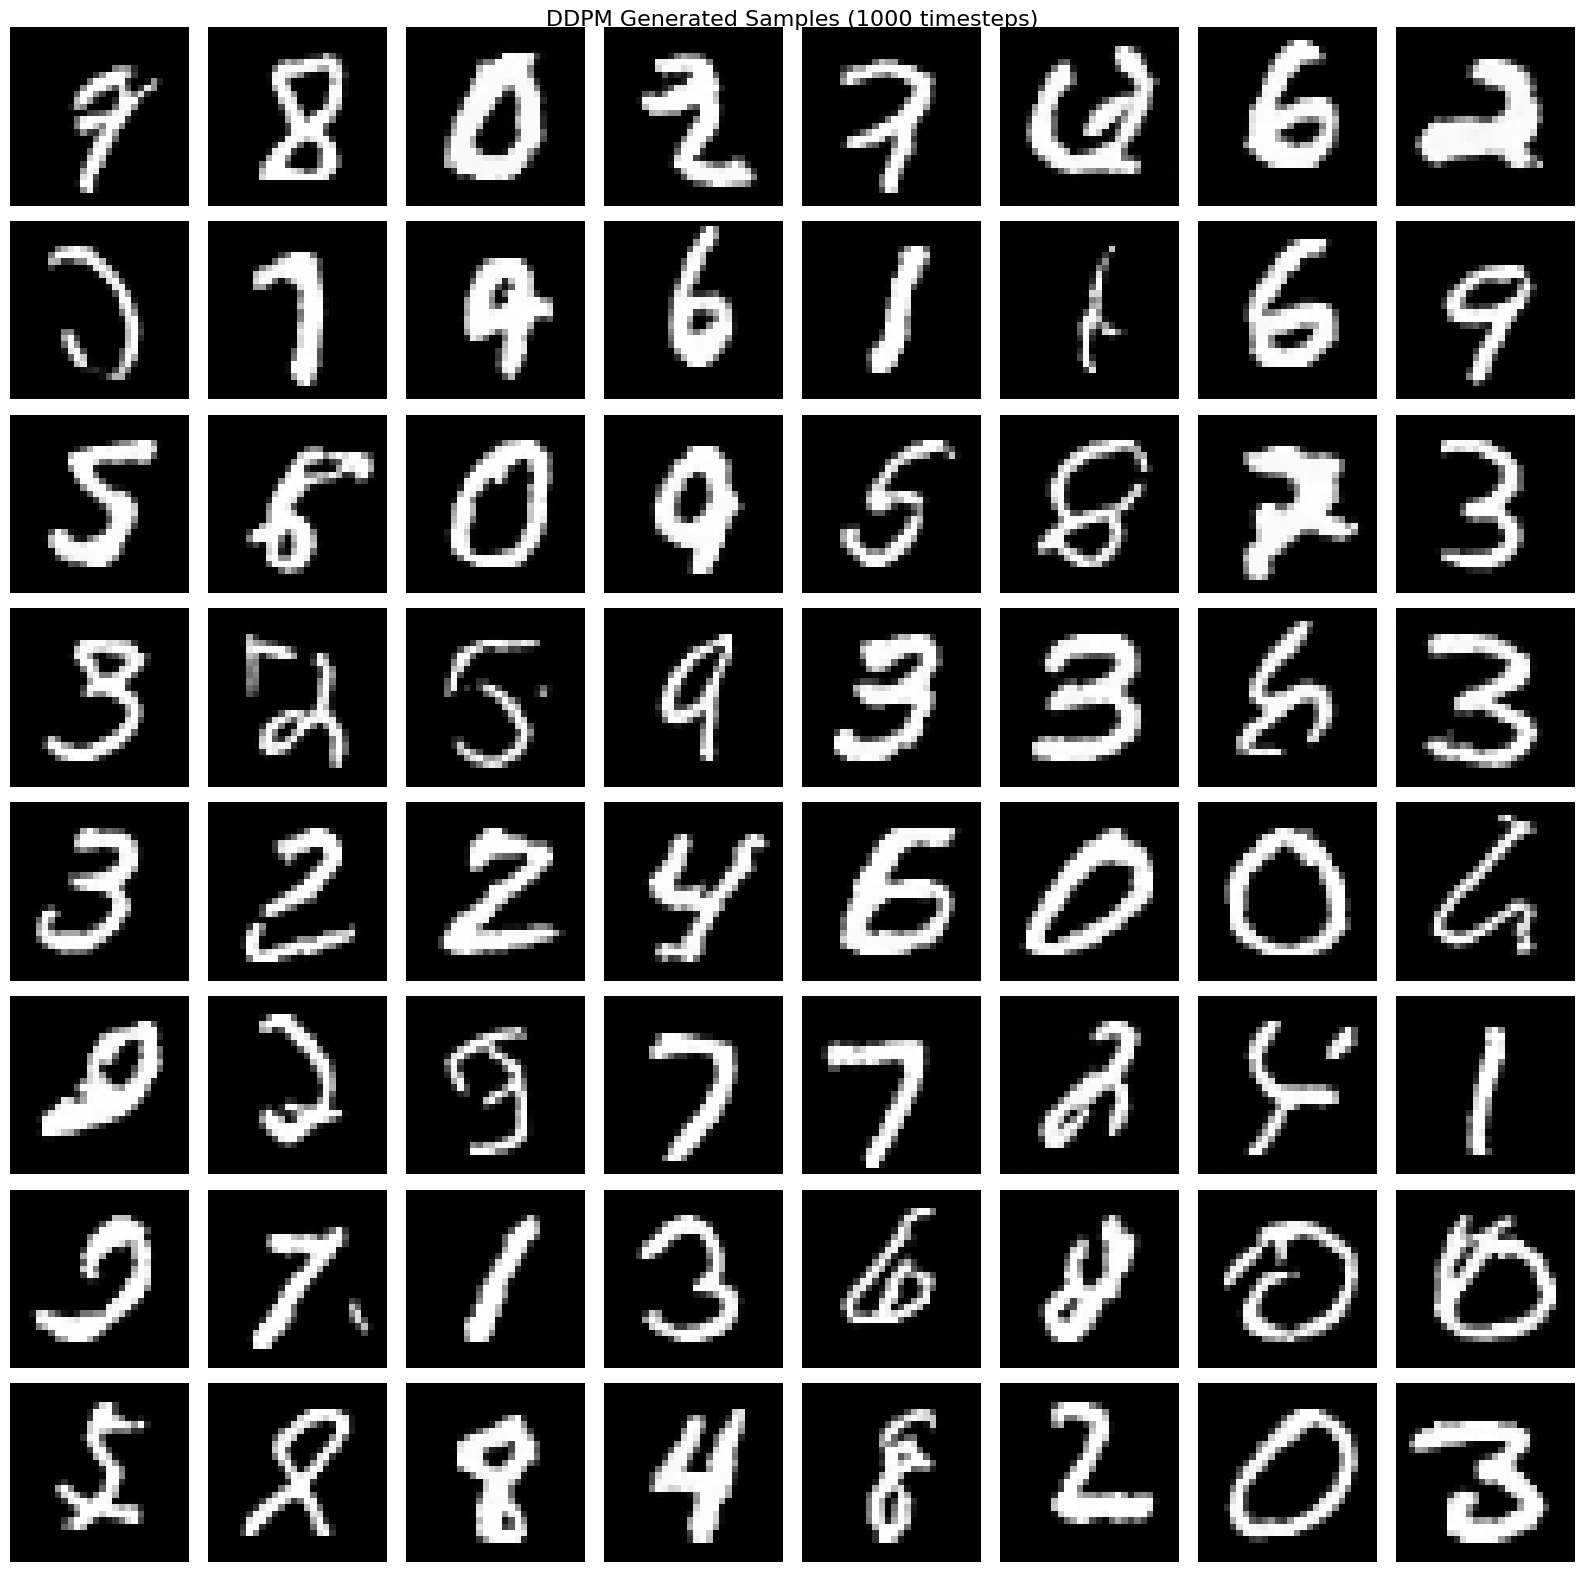

All numbers: 0 1 2 3 4 5 6 7 8 and 9 are recognizable but not in all samples

DDIM worked not so well

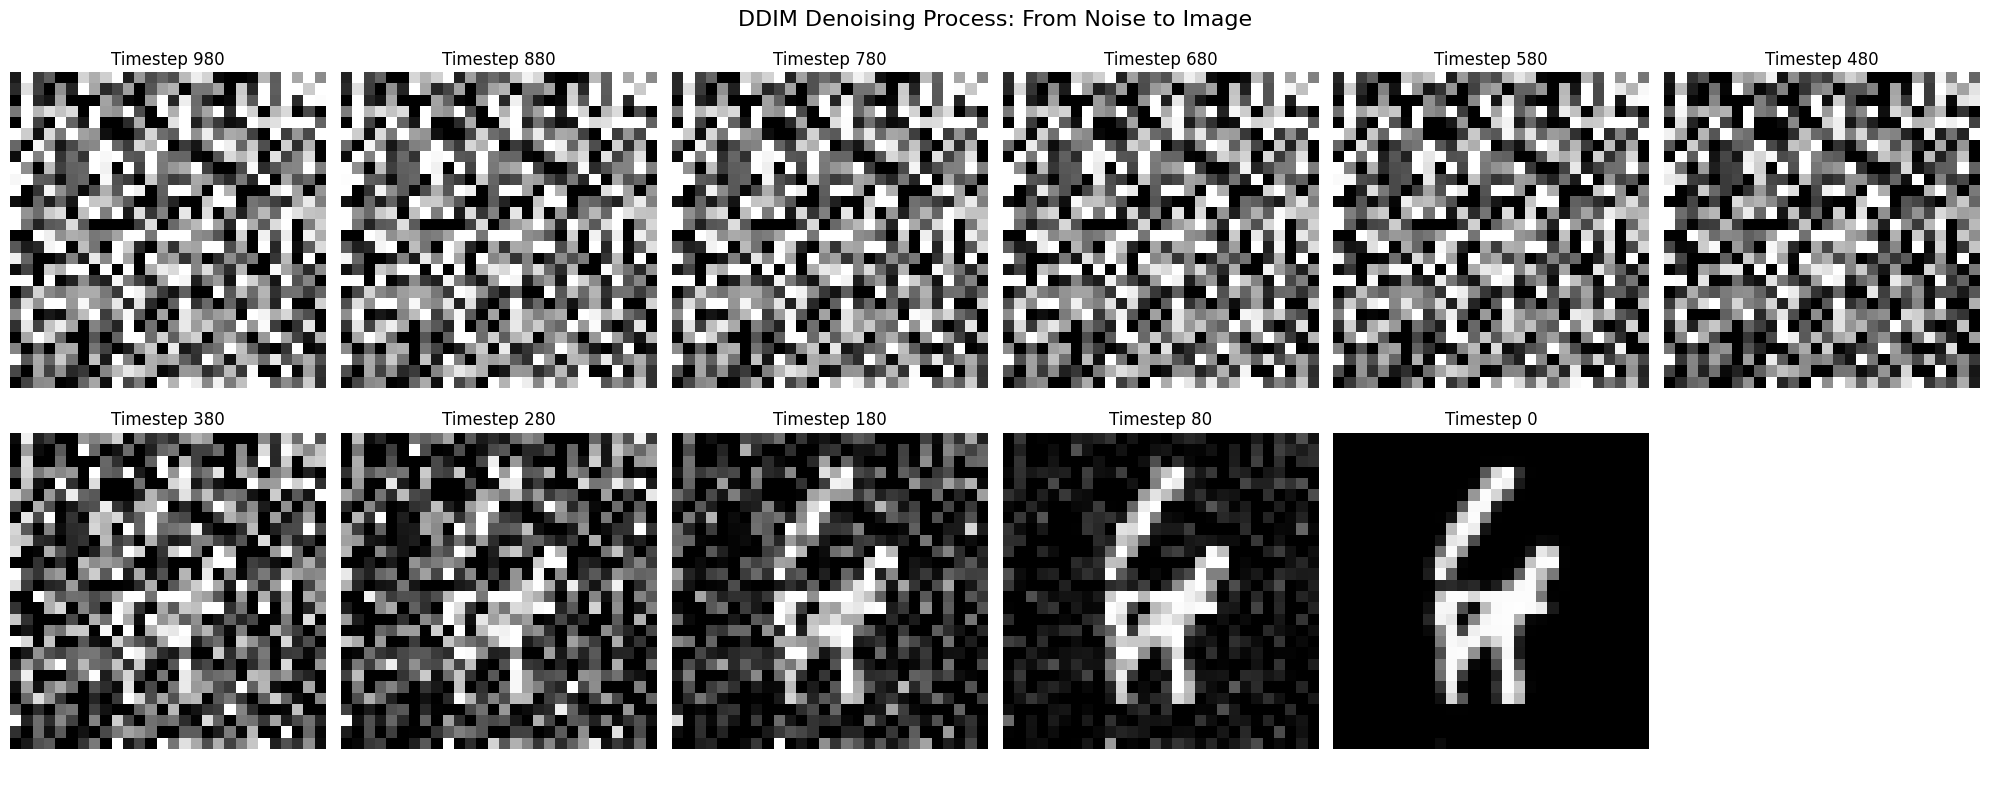

50 steps, DDIM sampling:

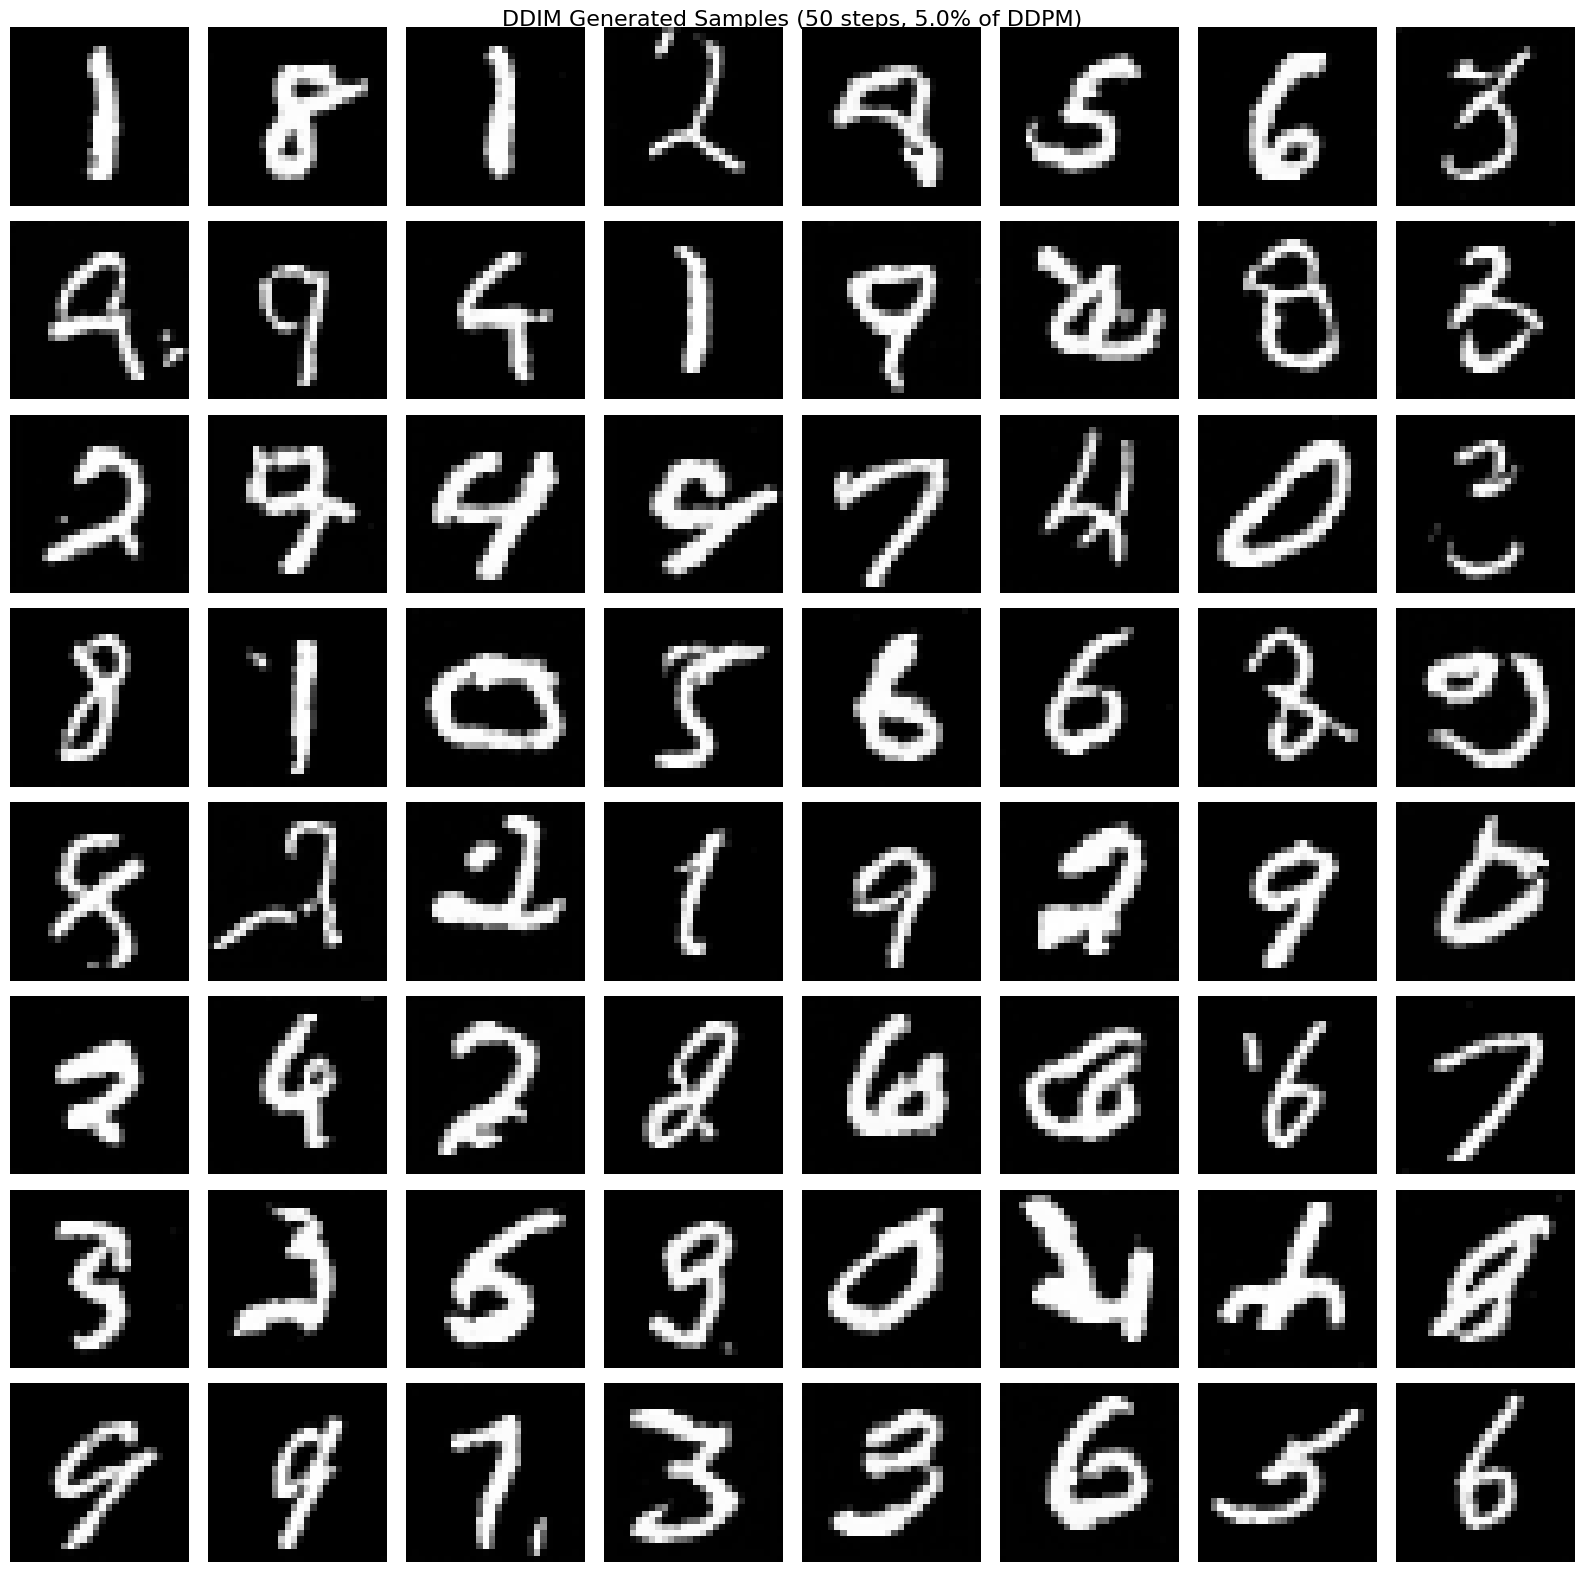

DDIM vs DDPM comparison:

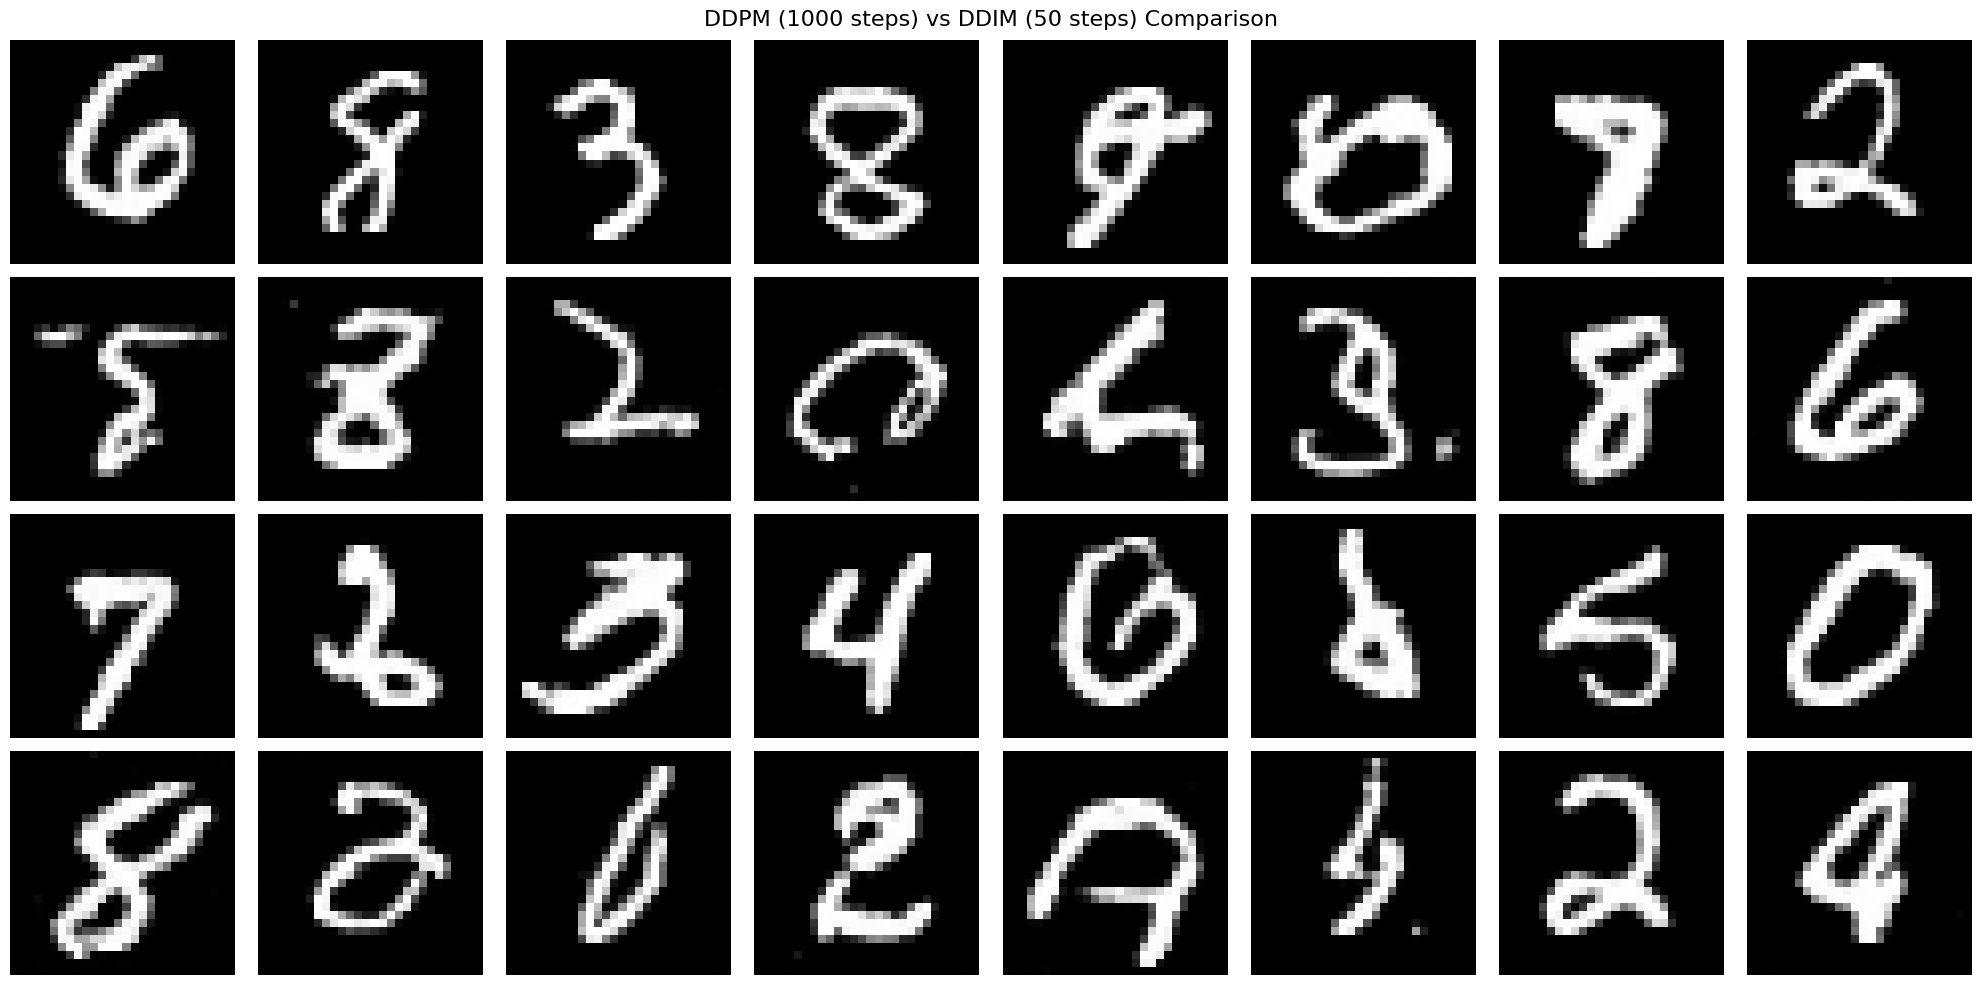

The top 16 digits are from standard DDPM (1000 steps), while the bottom 16 digits are from DDIM (50 steps). Despite the 20x speedup, the DDIM samples maintain visual quality comparable to the DDPM baseline. The plot looks like this deliberately, as our goal was to show that DDIM produces very similar results despite the significant speed improvement. The earlier denoising sample was an unfortunate digit; it looked much worse than the 9 (or 4?) from DDIM, but the larger sample selection helps show that the difference is not a significant issue.

###Extended run

I increased number of epochs to 50, dimension of unet from 128 to 256, learning rate 1e-4

<pre
># Training configuration
BATCH_SIZE = 128       # How many images to process at once
EPOCHS = 50            # Number of training epochs
LOG_INTERVAL = 100     # How often to print progress updates

# Model architecture
IMAGE_SIZE = 28        # MNIST image size (28x28)
IMAGE_CHANNELS = 1     # Grayscale images (1 channel)
HIDDEN_DIM = 256       # Base hidden dimension for UNet
TIMESTEPS = 1000       # Number of diffusion timesteps for DDPM

# DDIM configuration
DDIM_STEPS = 50        # Number of steps for DDIM sampling (much faster!)

# Diffusion-specific hyperparameters
LR = 1e-4              # Learning rate
BETA_START = 1e-4      # Starting noise level
BETA_END = 0.02        # Ending noise level

</pre>

DDPM on 50 epoch looks reasonably good:

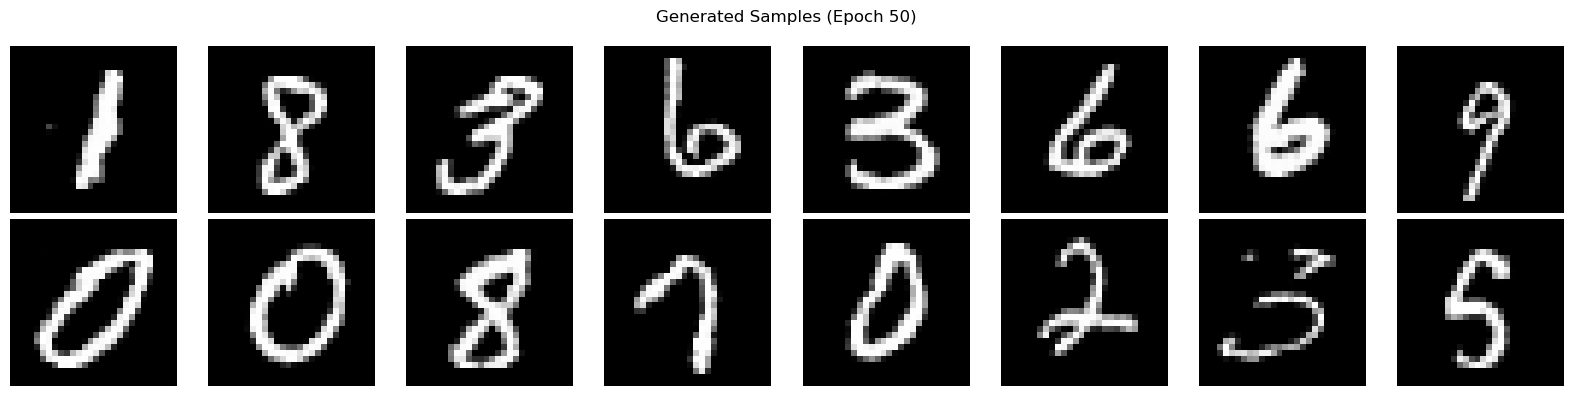

Final training loss: 0.021512

Took around 1 hour

Evaluation:

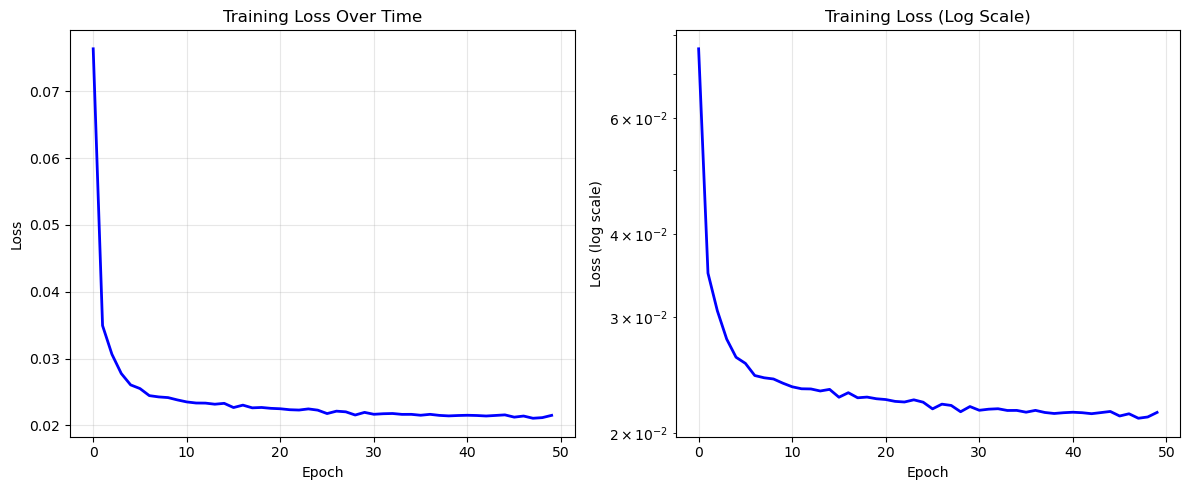

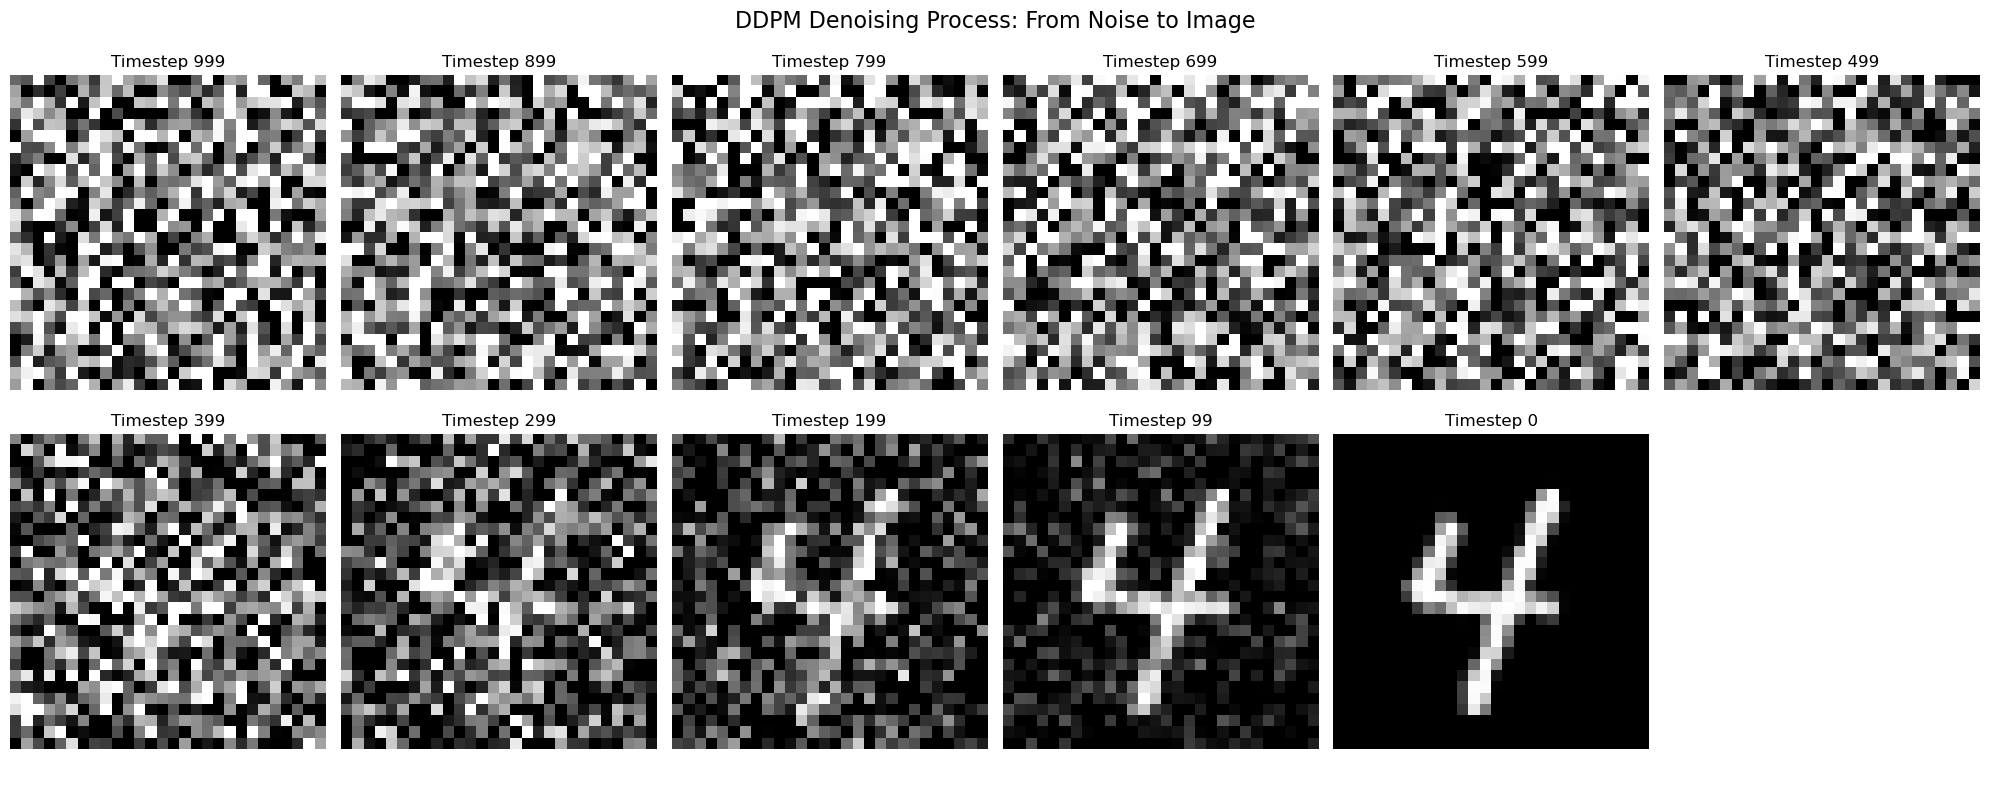

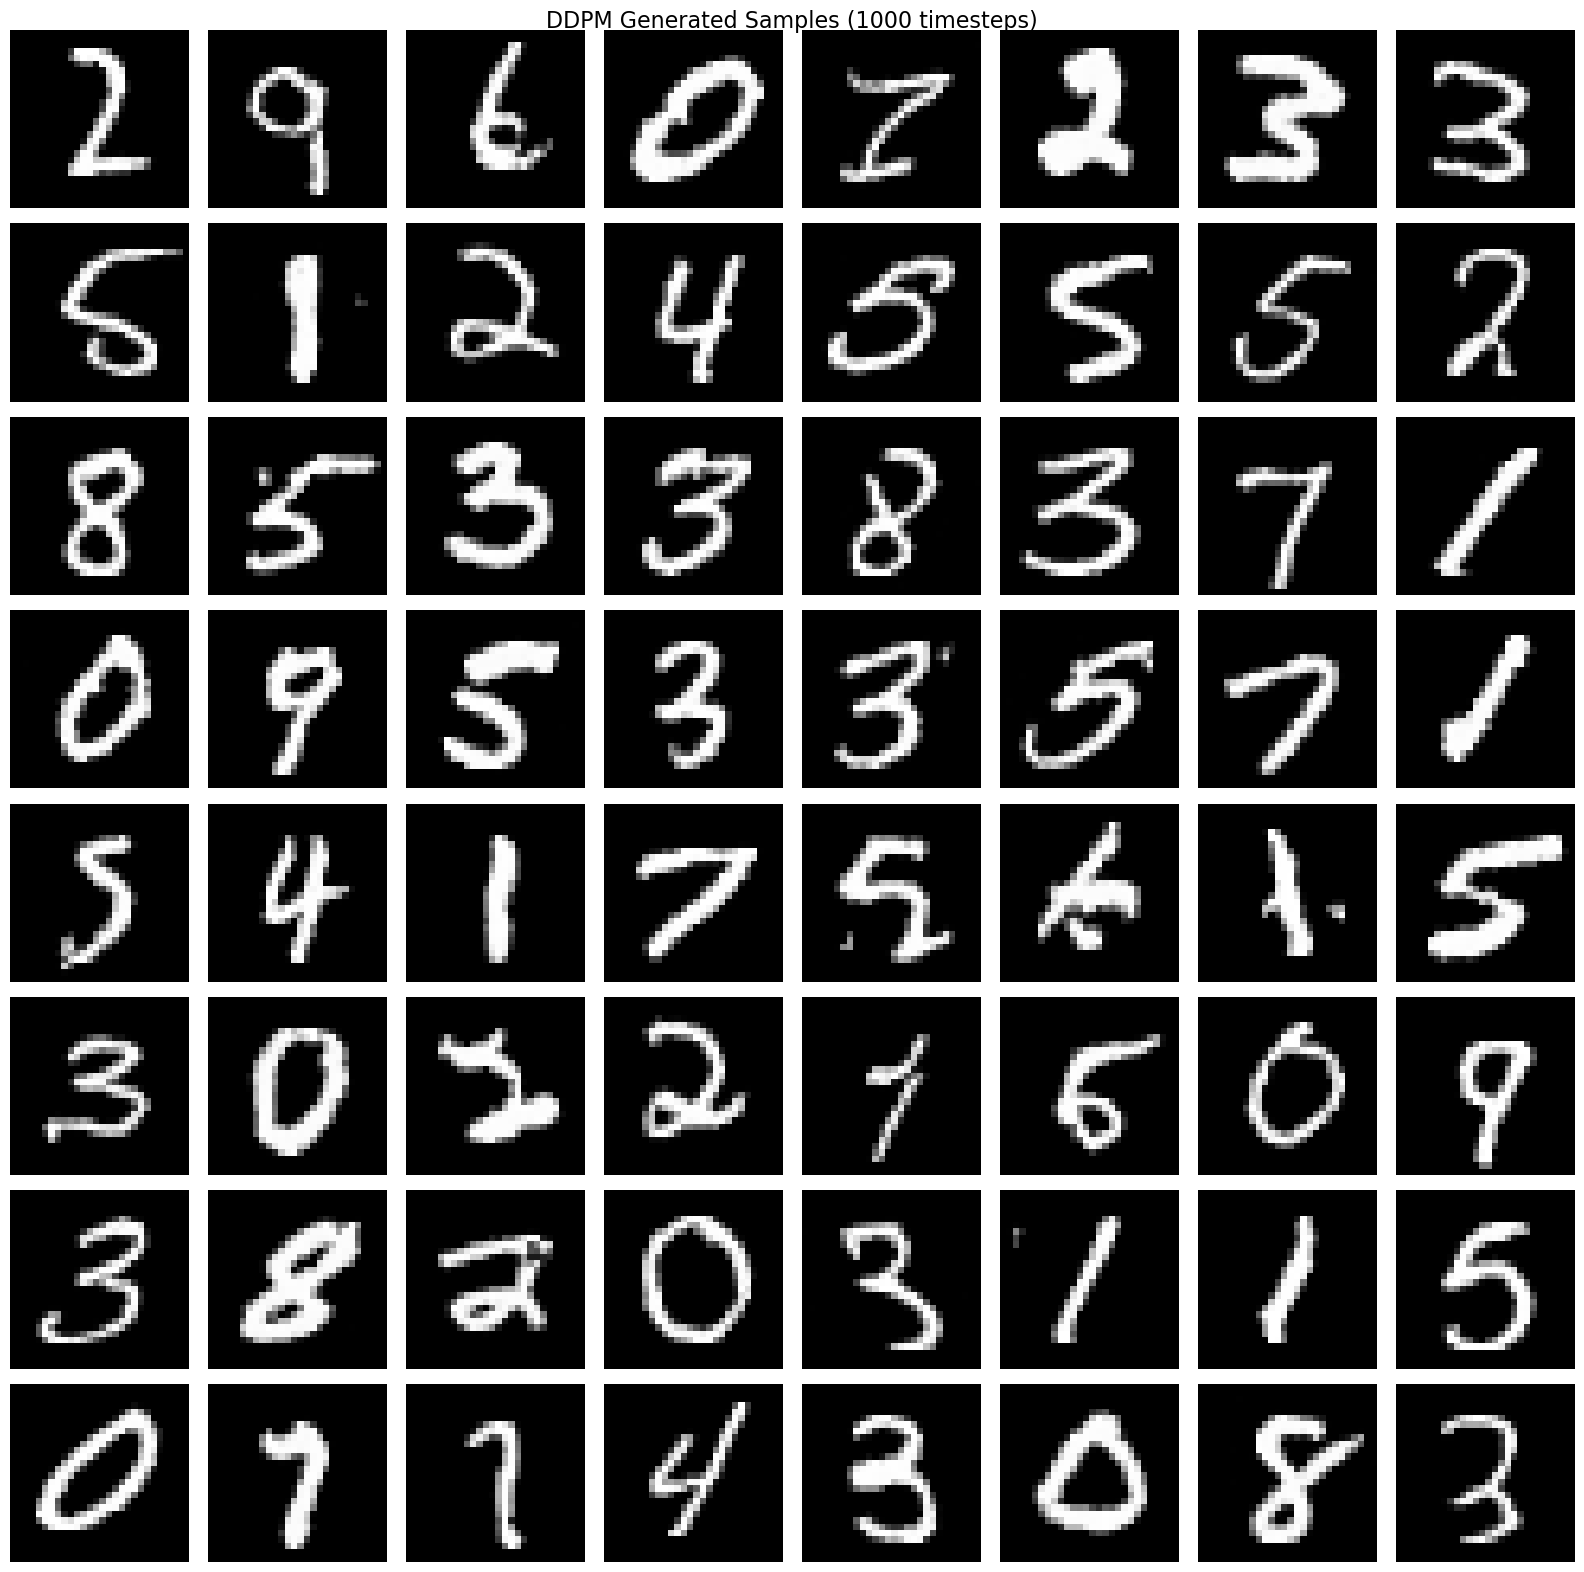

This time DDIM chose digit '1'. Could not be better (always could). With only small noisy pixel in corner.

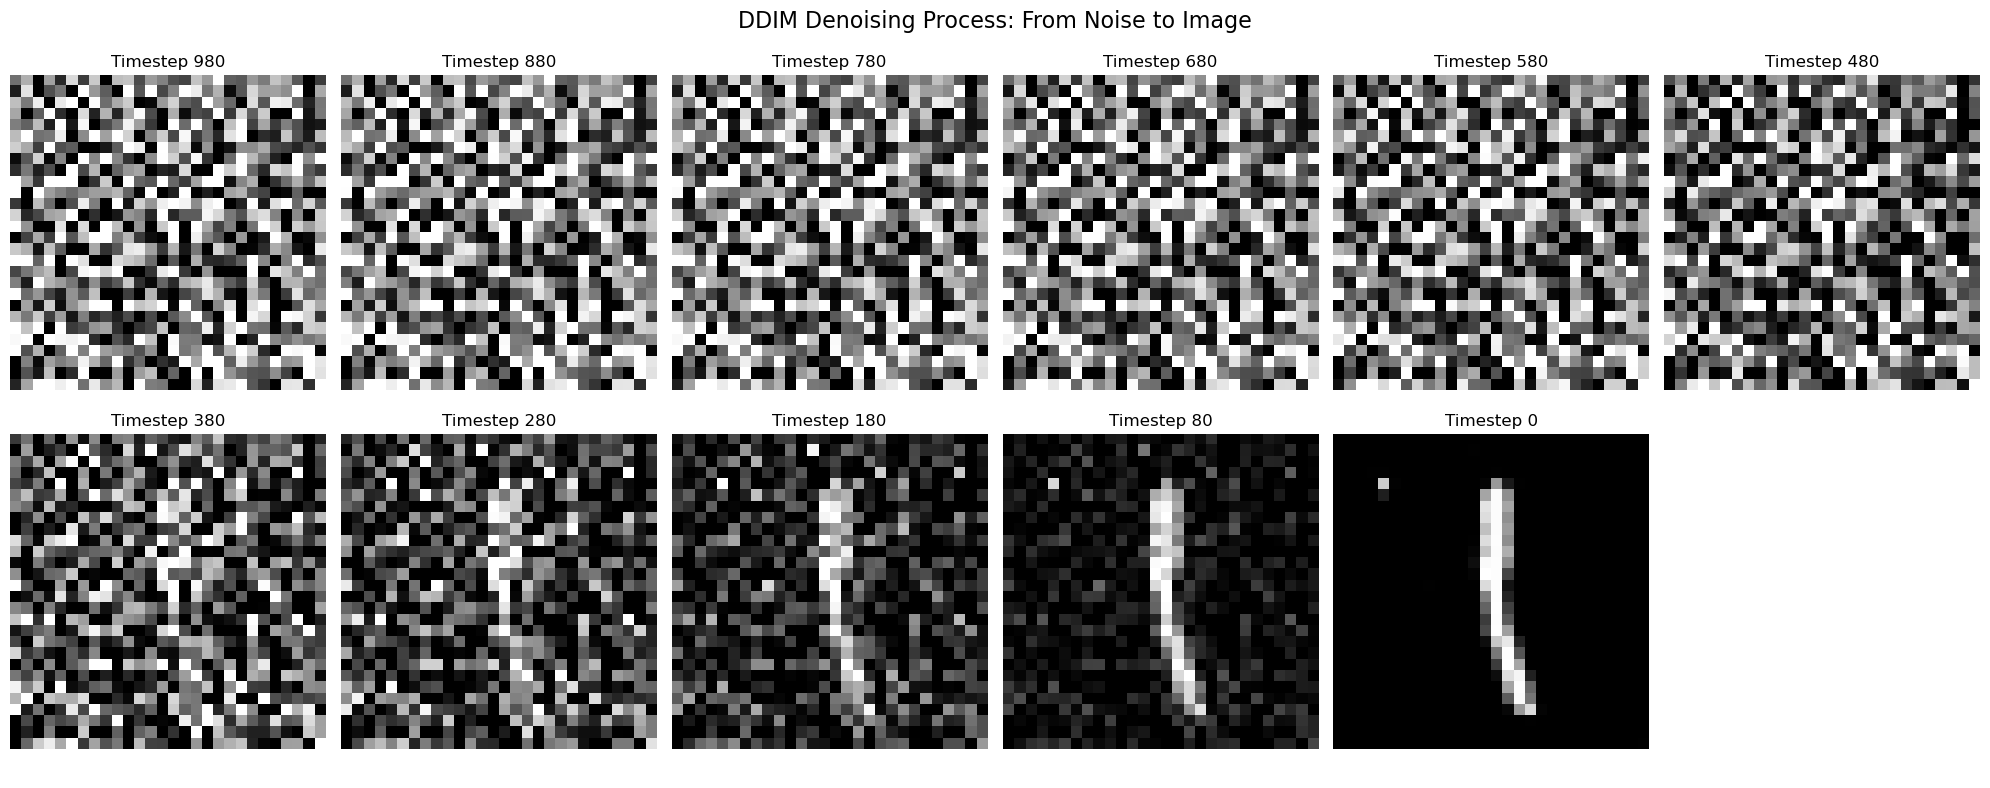

DDIM vs DDPM

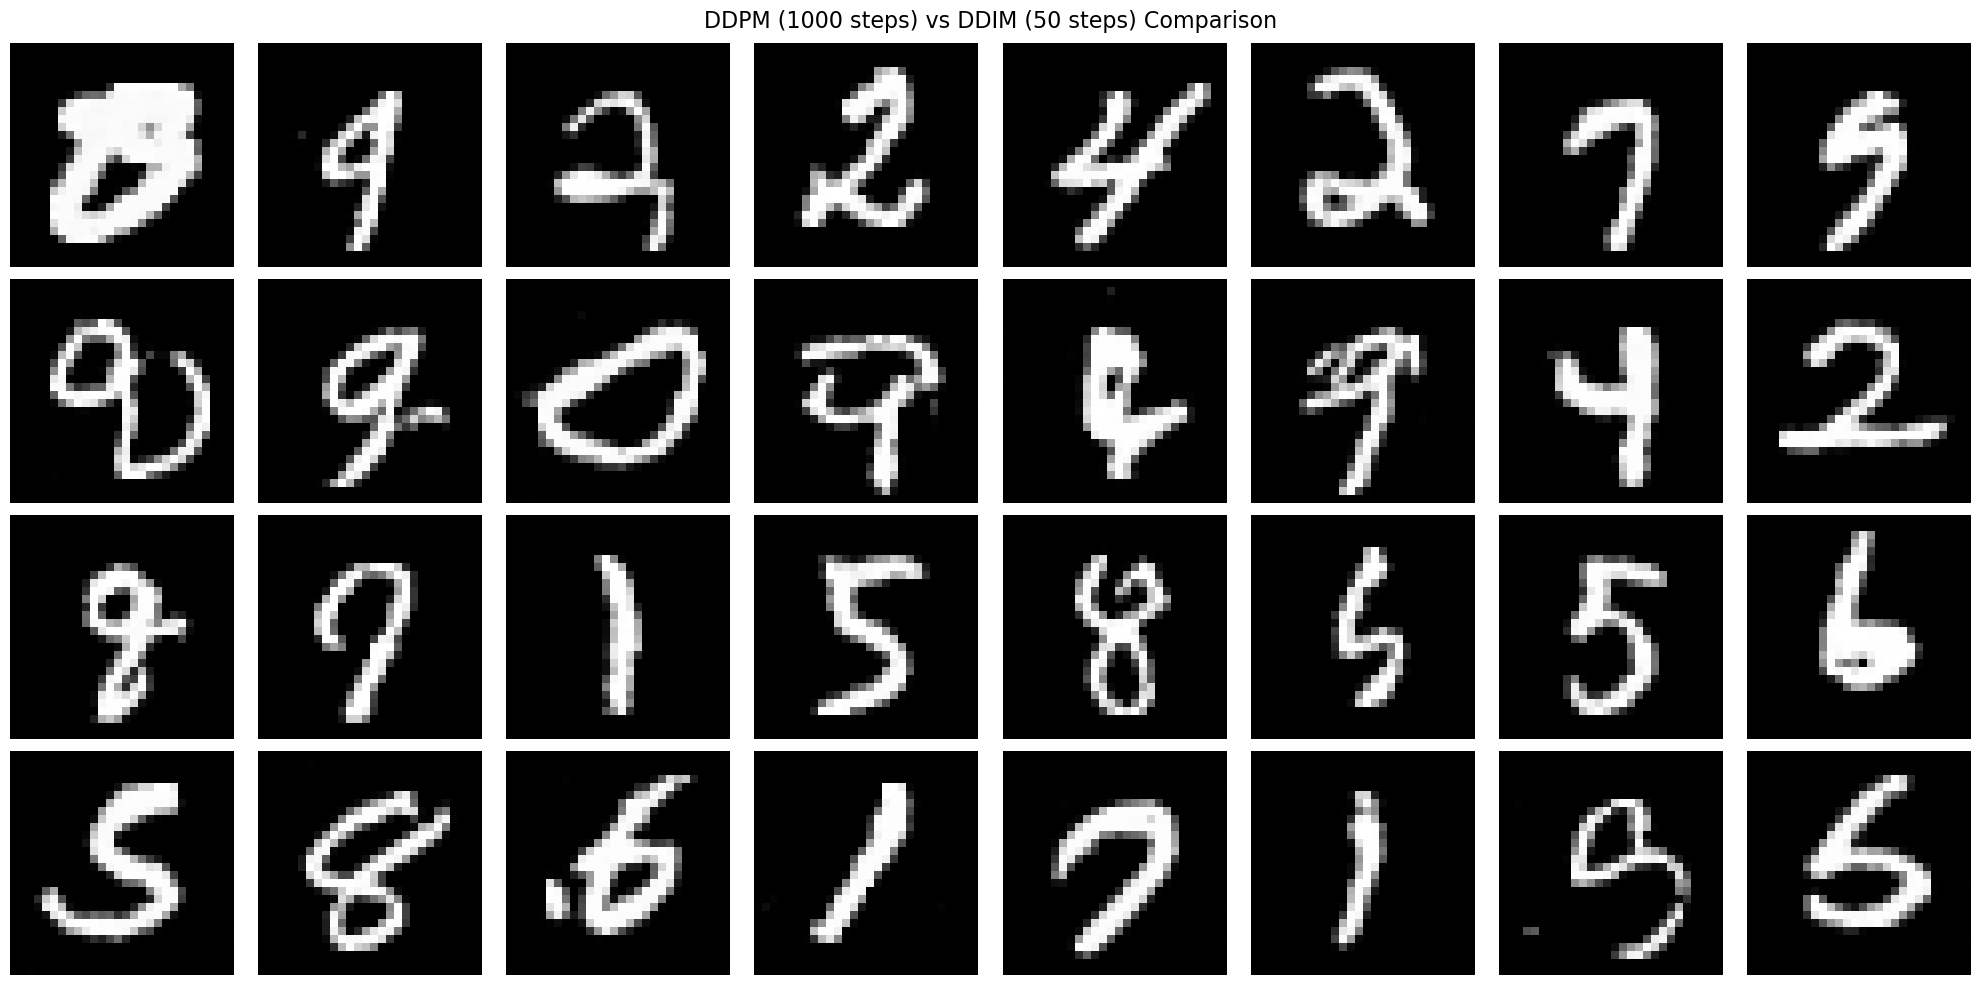

There is no much of an improvement. It just conforms that architecture choice is good.

### 100 epochs run

I will keep it short: with twice the epochs and time we gain almost nothing

DDPM

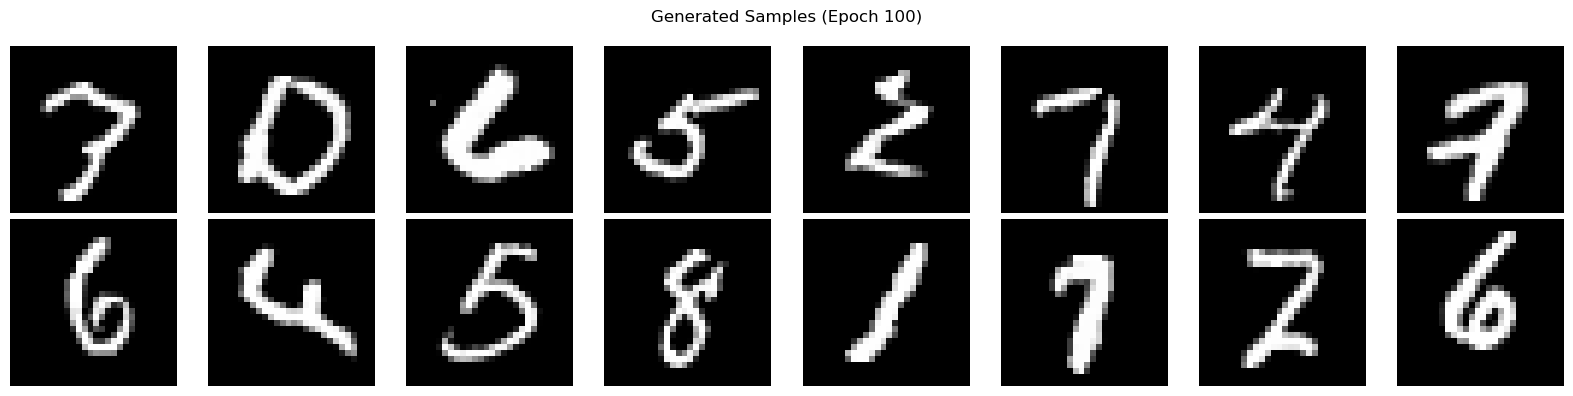

### EMA

I then introduced EMA (Exponential Moving Average). It is a technique that keeps a "smoother" copy of model's weights during training.

Normal training updates are noisy and "jittery." EMA maintains a shadow model that is an average of the model's weights over time. TIt could produce significantly cleaner and more stable generated images.

snippet:

```
class EMA:
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        # ... setup shadow params ...

    def update(self):
        # Formula: New_Shadow = (Decay * Old_Shadow) + ((1 - Decay) * Current_Weights)
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                # Code implementation of the formula
                self.shadow[name] -= (1 - self.decay) * (self.shadow[name] - param.data)
```

Stability: The EMA model produced more consistent digits with fewer random artifacts than the standard model.

Quality: The final samples looked cleaner.

'4' looks the best of all runs:

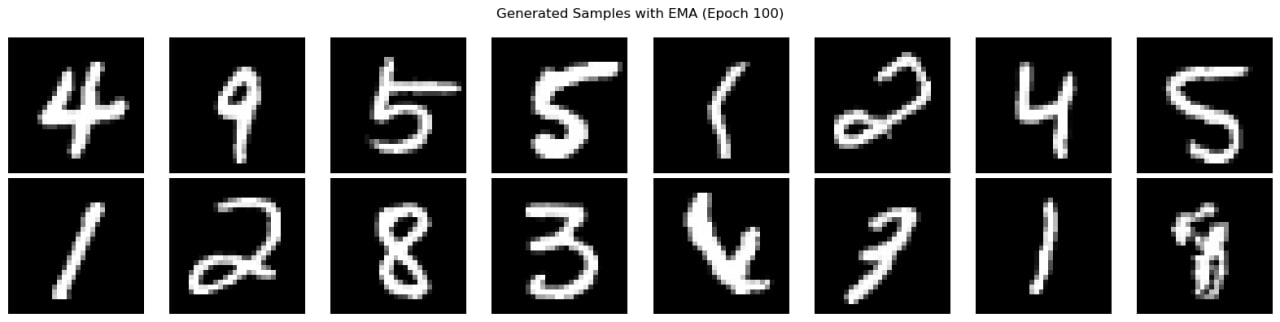

The training loss decreased almost linearly for the standard model. However, when switching to EMA weights at the final epoch, the loss "jumped" back to a value comparable to Epoch 50. This is due to EMA Lag.


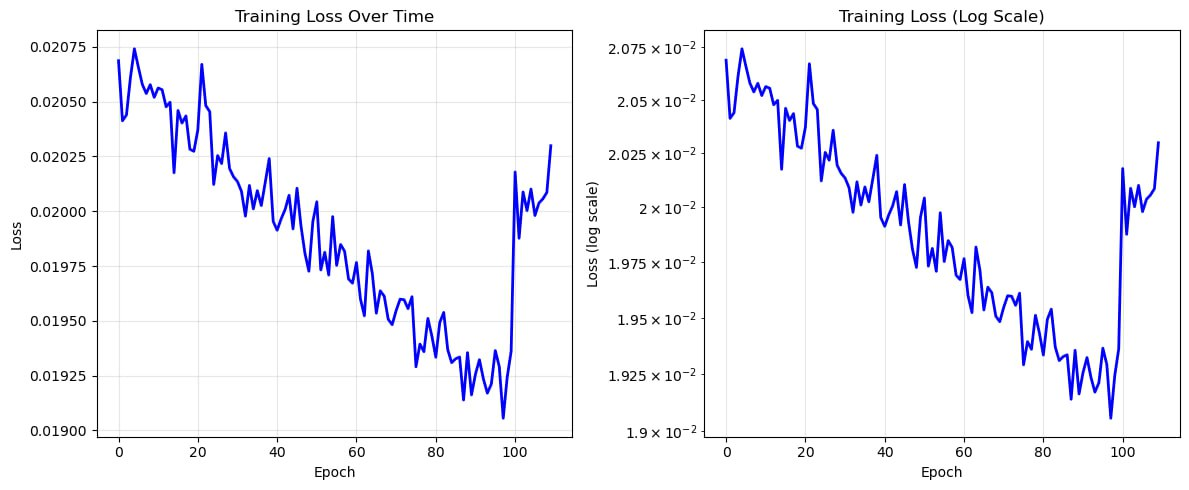

And very clean digits:

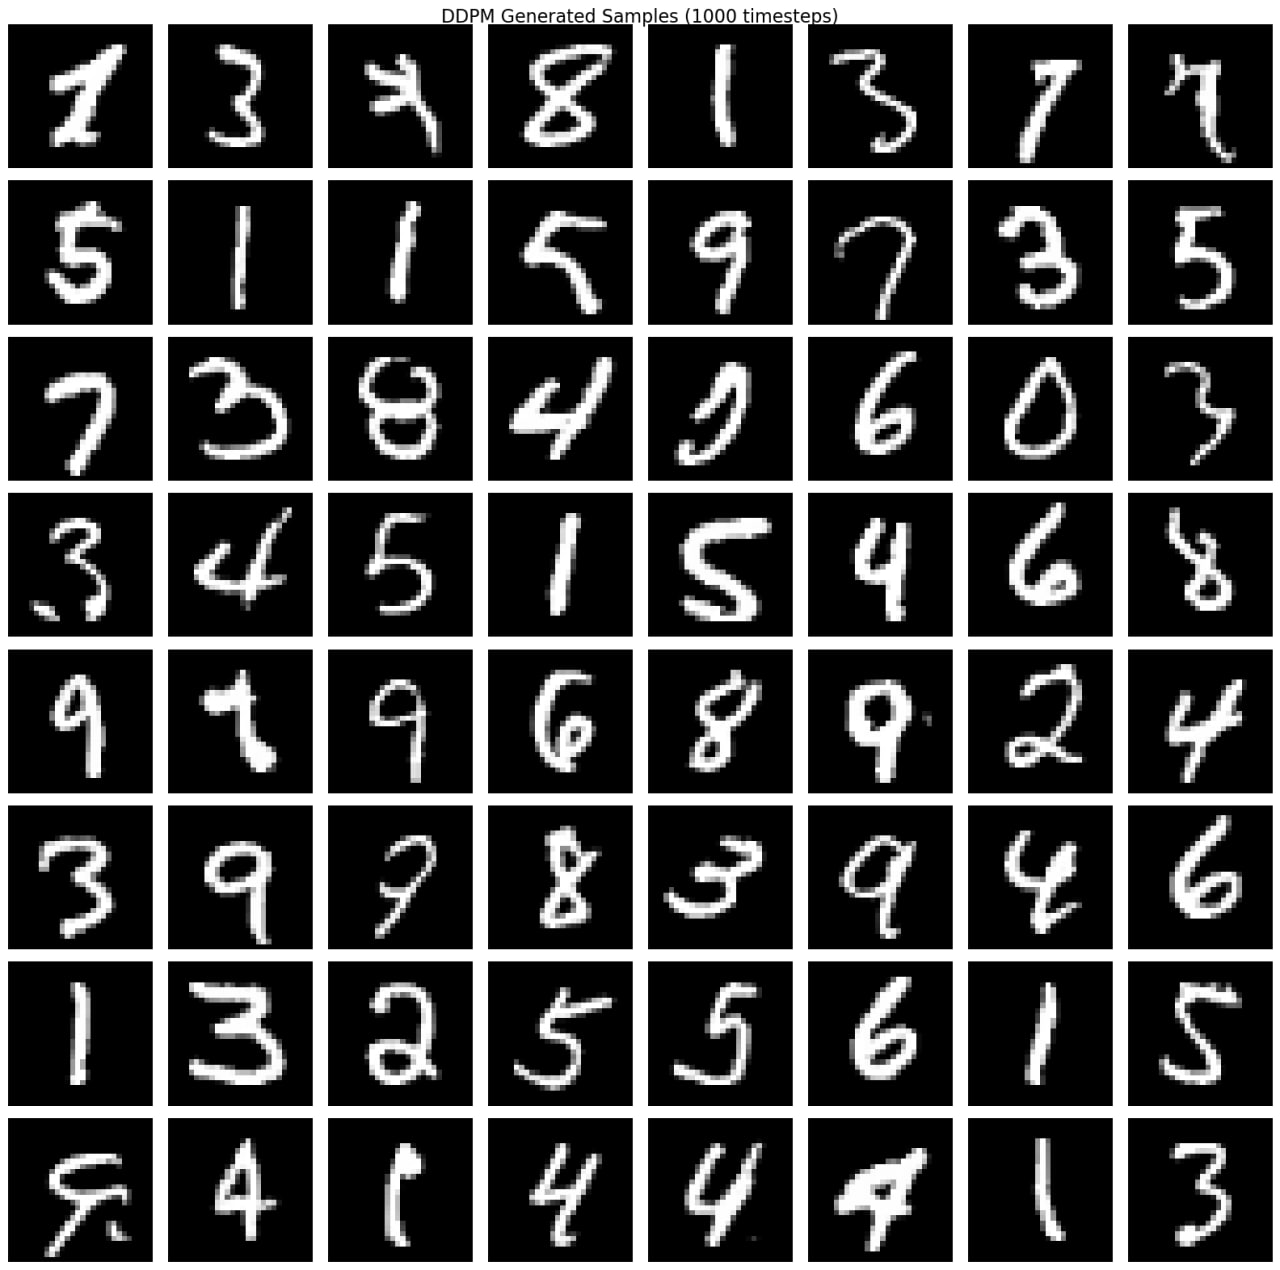

##Part 2 Latent Diffusion

Instead of adding noise directly to pixels, we'll use a VAE to compress images into a latent space, then run diffusion there. 28x28 to 7x7

Expectations:
- 5-10x faster training and sampling
- around twice less VRAM
- similar or even better image quality


I started from a simple mistale (using MSE instead of BCE loss) and got unacceptable result

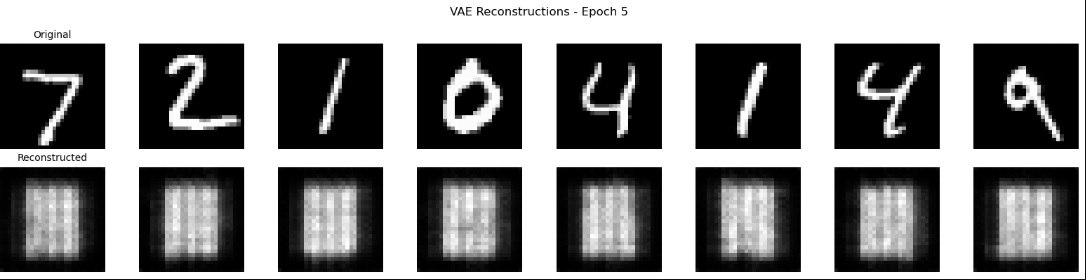

Wuth that fixed:

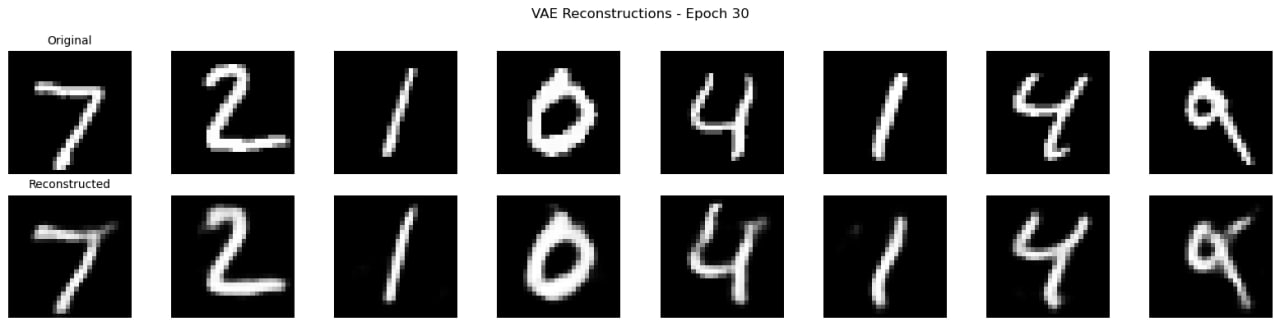

Digits are slightly blurry and some artifacts. Despite that all digits are recognizable and speed improvement was great (taking only 7 minutes instead of 50 mites to hour and half on DDPM)

VAE loss  and KL divergence snippet:

```

def vae_loss_fn(recon, x, mu, logvar, beta_kl=1.0):
    """
    VAE loss = Reconstruction Loss + KL Divergence
    
    Args:
        recon: Reconstructed images
        x: Original images
        mu: Latent mean
        logvar: Latent log variance
        beta_kl: Weight for KL divergence term
    
    Returns:
        total_loss, recon_loss, kl_loss
    """
    # Reconstruction loss (Binary Cross-Entropy)
    # BCE works better for image reconstruction than MSE
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)
    
    # KL divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = kl_loss / x.size(0)  # Average over batch
    
    # Total loss
    total_loss = recon_loss + beta_kl * kl_loss
    
    return total_loss, recon_loss, kl_loss

print("✅ VAE loss function defined!")


```

I made run and compared latent with fixed spoace on 100 vs 30 epochs. 100 epochs for ddpm could represent ground truth. It was well trained model that needed many computanional resources.

Speed vs. Quality comparison

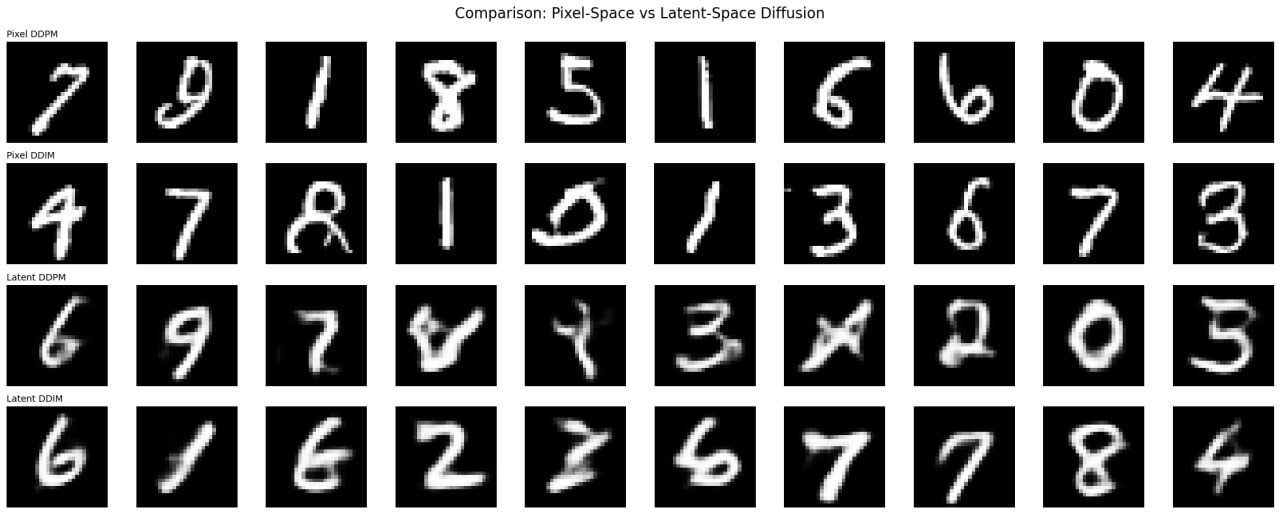

```
PERFORMANCE SUMMARY
============================================================

Model Parameters:
  Pixel U-Net:  27,741,953 parameters
  Latent U-Net: 16,555,396 parameters (1.7x smaller)

Generation Speed (64 samples):
  Pixel DDPM:   23.55s
  Pixel DDIM:   1.17s  (20.2x faster)
  Latent DDPM:  3.69s  (6.4x faster than Pixel DDPM)
  Latent DDIM:  0.15s  (155.9x faster than Pixel DDPM)

Key Insights:
  - Latent space reduces computation by operating on 4x7x7 instead of 1x28x28
  - DDIM provides deterministic sampling with fewer steps (50 vs 1000)
  - Combining both (Latent DDIM) gives maximum efficiency
```

Latent DDIM is the clear winner! It is 156x faster than the original Pixel DDPM (0.15s vs 23.55s).

Іmall $4 \times 7 \times 7$ vectors instead of full images made the model 1.7x smaller and significantly faster to train.

Even without latent space, switching from DDPM to DDIM cut generation time by 20x (1.17s vs 23.55s).

Pixel DDIM is crisp! Because it works on raw pixels, the digits are sharp and distinct.

Latent DDIM is slightly blurry. The digits look softer because they must be decoded by the VAE, which loses some fine detail during compression.

ConclusionL: Latent Diffusion trades a small amount of sharpness (visually detectable but still recogniuzable) for a massive (156x) gain in speed.

### Part 3 Classifier-Free Guidance

I almost immediately got into gpu error (out of bounds). I set num_classes=10 (digits 0-9), but for CFG, I passed a "null label" (usually 10) to represent "unconditional". The model tried to look up index 10 in an embedding table of size 10 and instantly crashed. All model and weights form part I and part II are gone.

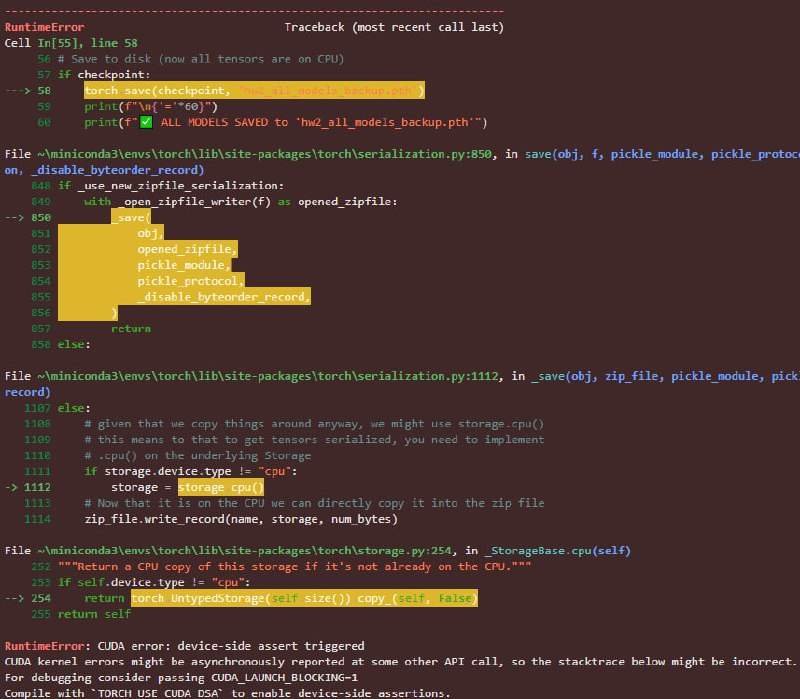

I tried reciverung, cleared cache, moved to cpu. But it did not help.

Okay. let's move on with restarting kernel.

### Method 1: Input concatenation (simple, efficient)
I modofied U-NEt to accept class labels via concatenation.

Train: we randomly drop labels with probability CFG_DROPOUT (which was 0.1) and replace them with the null token. This teaches the model both conditional and unconditional generation.

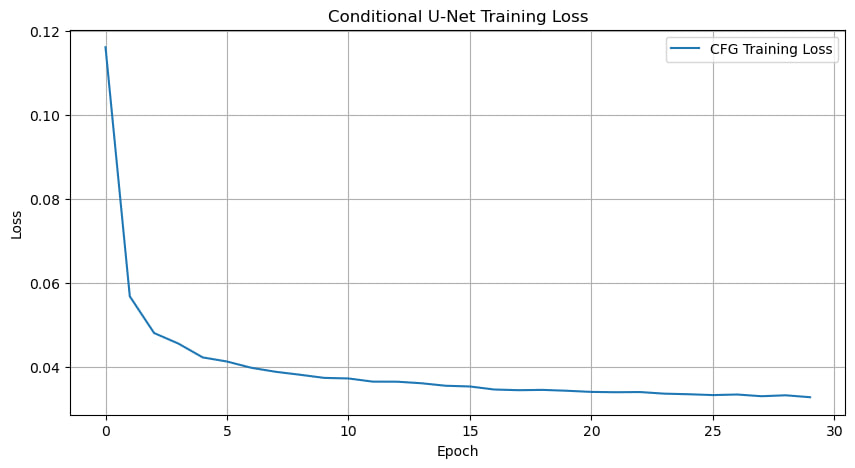

```
Training Conditional U-Net with CFG for 30 epochs...
Epoch [5/30] Loss: 0.042315
Epoch [10/30] Loss: 0.037444
Epoch [15/30] Loss: 0.035571
Epoch [20/30] Loss: 0.034378
Epoch [25/30] Loss: 0.033551
Epoch [30/30] Loss: 0.032842
Training complete!
```

Training loss looks okay. Even good. And image...

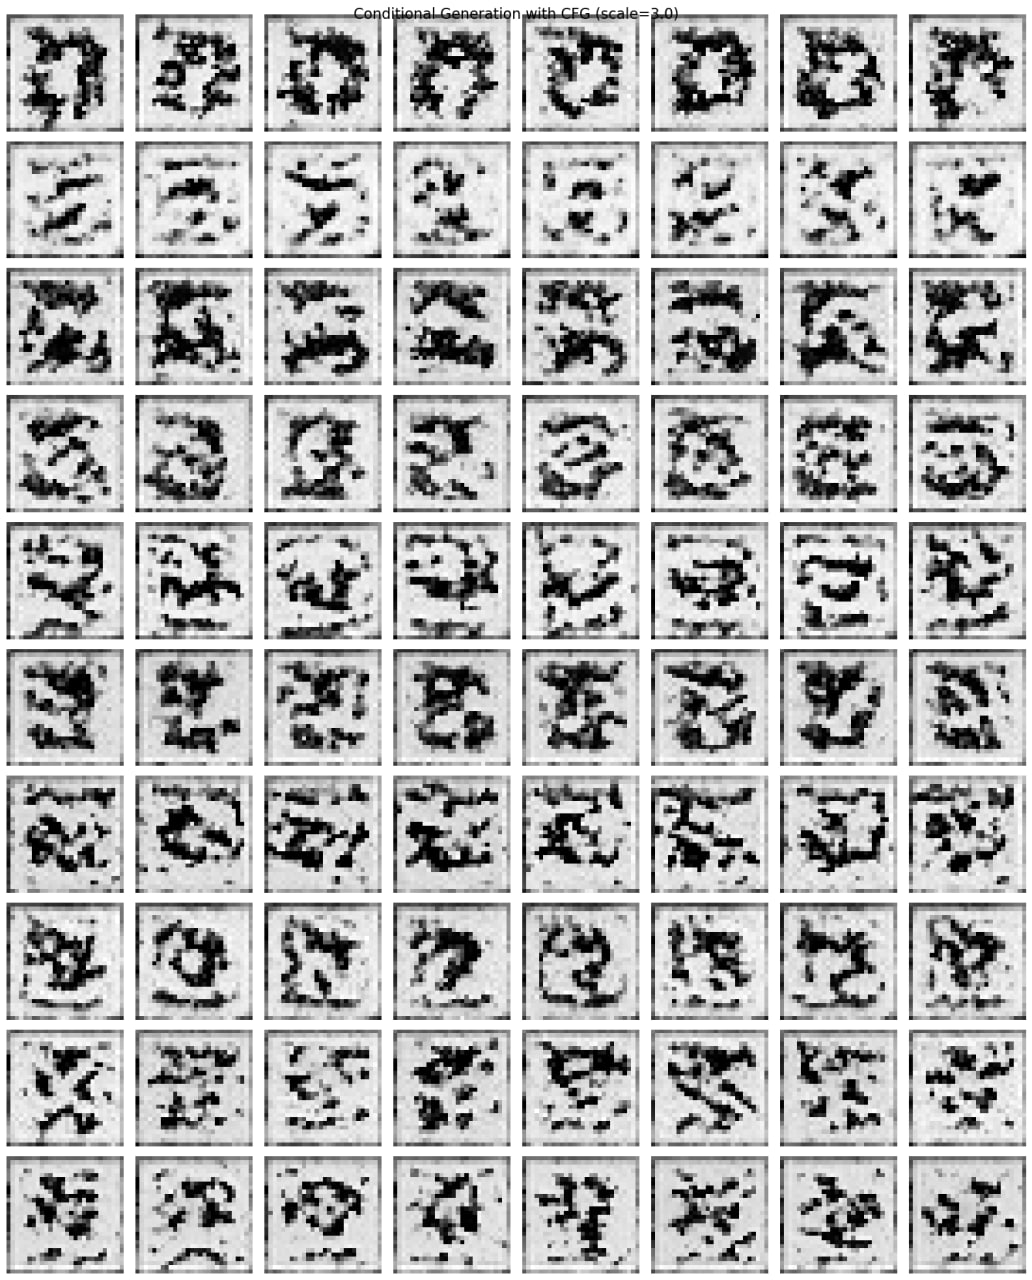

Just terrible. Issue was trivial: training uses no normalization - images stay in [0, 1] range. But Part 3 CFG training normalizes to [-1, 1]

Once more. Contantentation with one-hot encoding:

11 channels for one-hot → 12 input channels
Fixed, no efficient training

snippet:

```
class ConditionalUNet_OneHot(nn.Module):
    """Conditional U-Net using one-hot class encoding."""
    
    def __init__(self, num_classes=10, time_emb_dim=256):
        super().__init__()
        self.num_classes = num_classes
        self.null_token = num_classes  # Class 10 for unconditional
        
        # Time embedding
        self.time_embed = nn.Sequential(
            SinusoidalPositionalEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
        )
        
        # Input: 1 (image) + 11 (one-hot with null) = 12 channels
        self.encoder = ResidualBlock(12, 64, time_emb_dim)
        # ... rest of U-Net architecture
    
    def forward(self, x, t, labels):
        """
        Args:
            x: (B, 1, 28, 28) noisy images
            t: (B,) timesteps
            labels: (B,) class labels (0-9) or 10 (null)
        """
        t_emb = self.time_embed(t)
        
        # Convert to one-hot: (B,) -> (B, 11)
        labels_oh = F.one_hot(labels, num_classes=self.num_classes + 1).float()
        # Expand to spatial: (B, 11) -> (B, 11, 28, 28)
        labels_oh = labels_oh.view(-1, 11, 1, 1).expand(-1, -1, 28, 28)
        
        # Concatenate with image: (B, 12, 28, 28)
        x_cond = torch.cat([x, labels_oh], dim=1)
        
        # Pass through U-Net
        return self.unet(x_cond, t_emb)
```

Visualization of how CFG strength affects class-conditional image quality and diversity:

Scale 0.0: Unconditional (ignores label, random digits)

Scale 1.0: Standard conditional (follows label)

Scale 3.0: Stronger conditioning (clearer, more consistent)

Scale 7.0: Very strong (sharpest, but less diverse)

Qaulity vs diversity trade-off




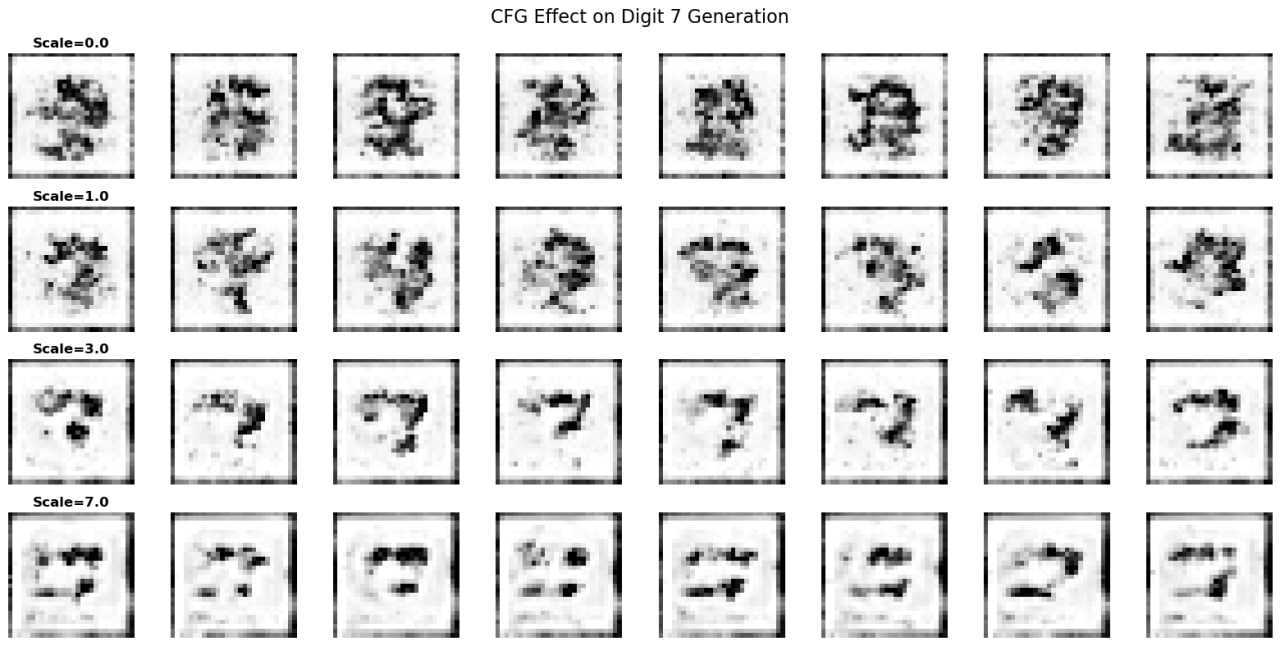

snippet for learned embeddings:

```
class ConditionalUNet_Embedding(nn.Module):
    """Conditional U-Net using learned class embeddings."""
    
    def __init__(self, num_classes=10, time_emb_dim=256, class_emb_dim=16):
        super().__init__()
        self.num_classes = num_classes
        self.null_token = num_classes  # Class 10 for unconditional
        
        # Time embedding
        self.time_embed = nn.Sequential(
            SinusoidalPositionalEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
        )
        
        # Learned class embedding (11 classes including null)
        self.class_embed = nn.Embedding(num_classes + 1, class_emb_dim)
        # Project to spatial map
        self.class_proj = nn.Linear(class_emb_dim, 28 * 28)
        
        # Input: 1 (image) + 1 (class map) = 2 channels
        self.encoder = ResidualBlock(2, 64, time_emb_dim)
        # ... rest of U-Net architecture
    
    def forward(self, x, t, labels):
        """
        Args:
            x: (B, 1, 28, 28) noisy images
            t: (B,) timesteps
            labels: (B,) class labels (0-9) or 10 (null)
        """
        t_emb = self.time_embed(t)
        
        # Learned embedding: (B,) -> (B, class_emb_dim)
        class_emb = self.class_embed(labels)
        # Project to spatial: (B, class_emb_dim) -> (B, 28*28) -> (B, 1, 28, 28)
        class_map = self.class_proj(class_emb).view(-1, 1, 28, 28)
        
        # Concatenate with image: (B, 2, 28, 28)
        x_cond = torch.cat([x, class_map], dim=1)
        
        # Pass through U-Net
        return self.unet(x_cond, t_emb)
```

```
┌─────────────────────┬──────────────┬──────────────────┐
│ Metric              │ One-Hot      │ Embeddings       │
├─────────────────────┼──────────────┼──────────────────┤
│ Input channels      │ 12           │ 2                │
│ Class params        │ 0 (fixed)    │ 176 (11×16)      │
│ U-Net params        │ ~18.5M       │ ~16.2M (-12%)    │
│ Total params        │ ~18.5M       │ ~16.2M           │
│ Memory efficient    │ ❌           │ ✅               │
│ Learned repr.       │ ❌           │ ✅               │
│ Flexibility         │ Low          │ High             │
└─────────────────────┴──────────────┴──────────────────┘
```

Slighlty better:

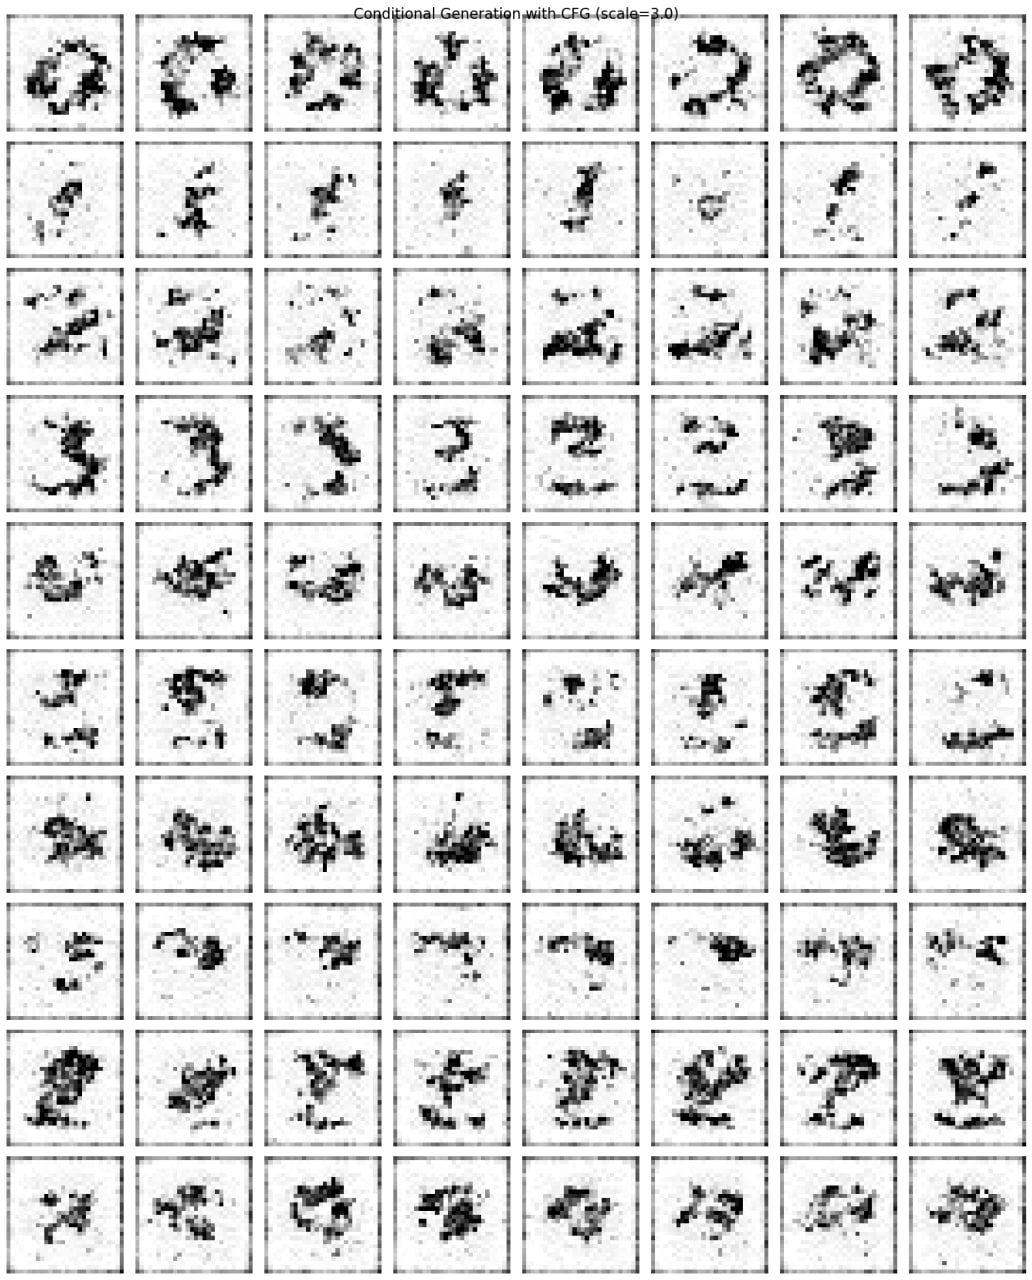

Let's run with 50 ecpochs, dual conditioning - class information added to both
time embeddings (via addition) and
Spatial concatenation (as before). Larger embeddings: 128-dim instead of 64-dim. LR: 2e-4. deeper projection network:


```
CFG_EPOCHS = 50  # Increased - embeddings need more training
CFG_BATCH_SIZE = 256
CFG_LR = 2e-4  # Slightly higher learning rate
CFG_DROPOUT = 0.1  # Probability of dropping class label during training
CLASS_EMB_DIM = 128  # Larger embedding dimension
```

Even worse:

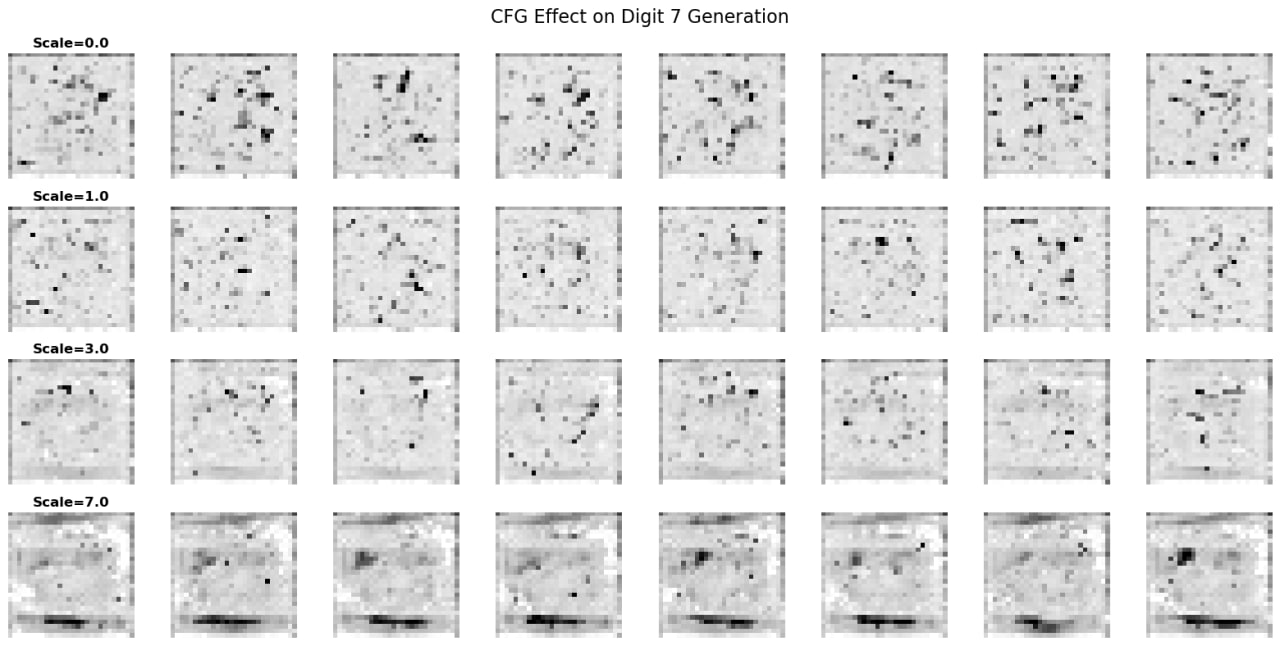



Now, after some tweaking and optimization. Looked like I did overkill on parameters and dimensions for MNIST.

Parameters: 4.0M → ~2.0M (50% reduction!)

reducing dimensions to:

time_emb_dim=128, class_emb_dim=64

Simplified Time Embedding

```
# After: 2-layer (just embedding + activation)
self.time_embed = nn.Sequential(
    SinusoidalPositionalEmbedding(time_emb_dim),
    nn.Linear(time_emb_dim, time_emb_dim),
    nn.SiLU()
)
```

Simpler class - to -time projection (single linear layer)

```
self.class_to_time = nn.Linear(class_emb_dim, time_emb_dim)
```

and more importantly, eliminating double normalization!

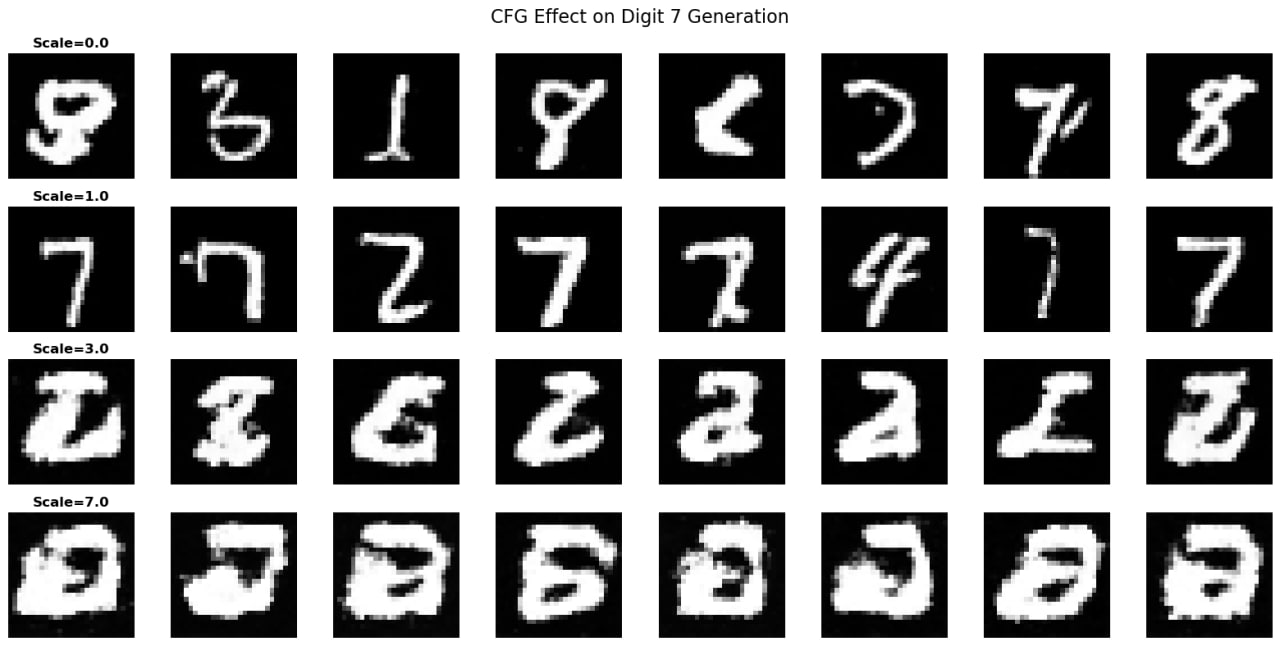

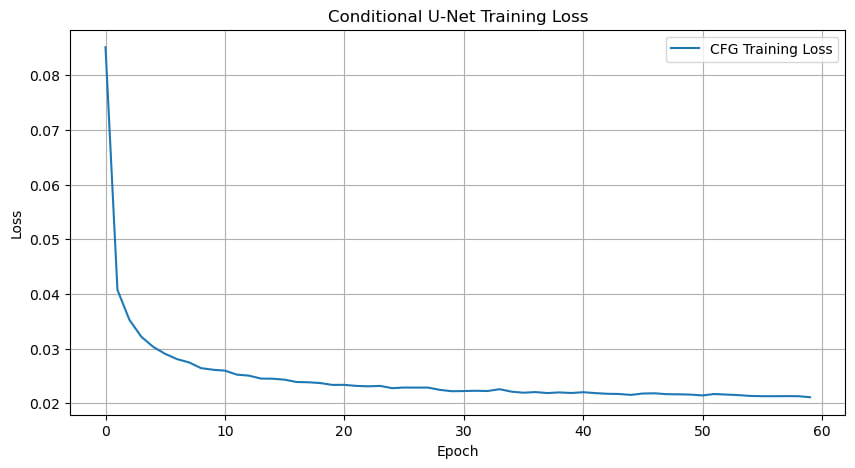

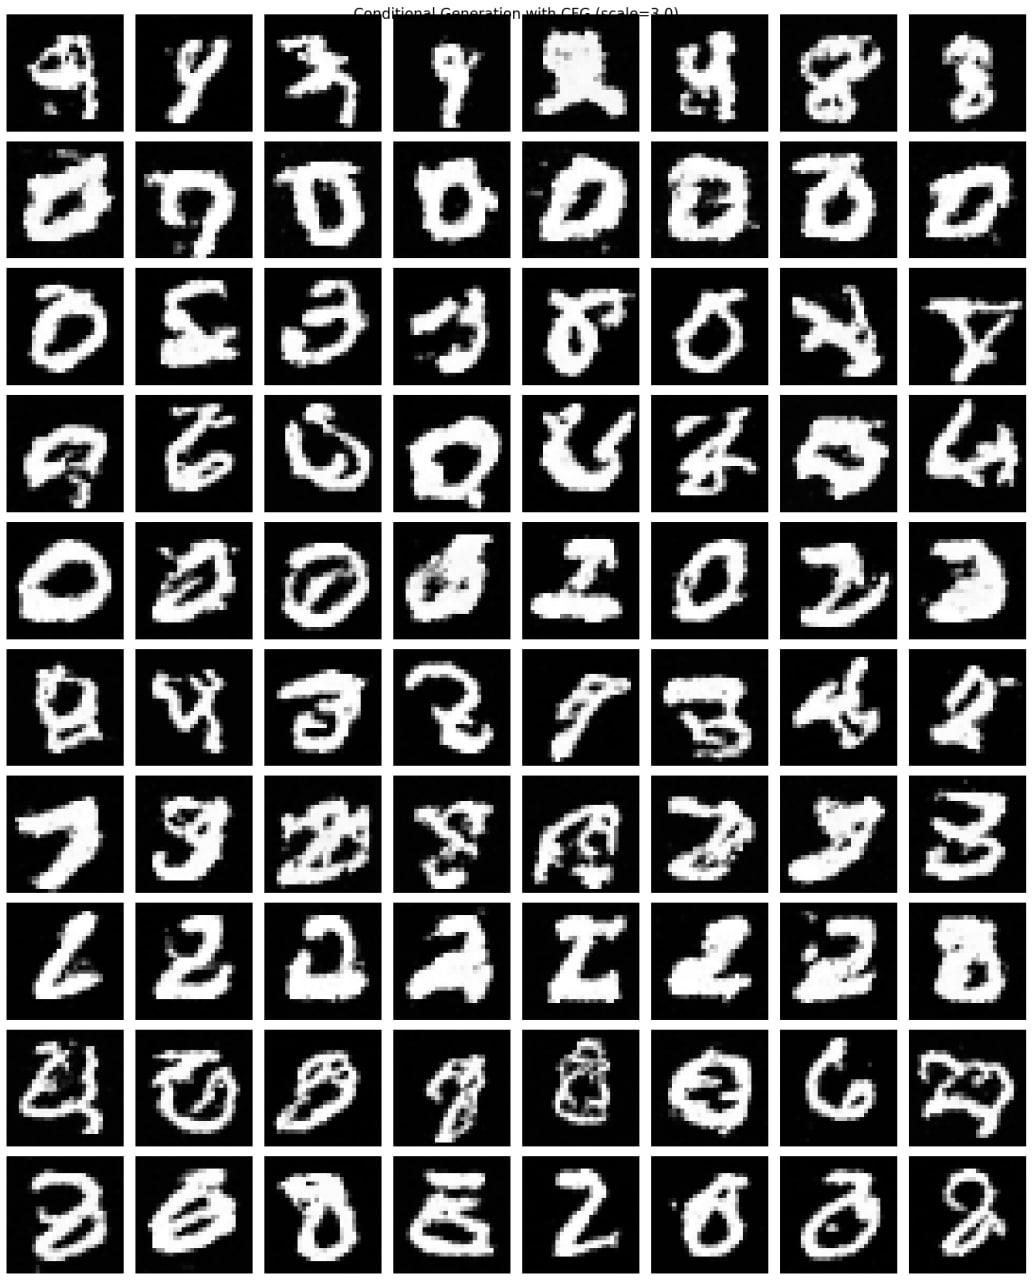

That last run showed reasonably well results. Reasonably given it's constraints and speed efficiency. It's almost always a tradeoff. 60 epochs run took about 15 minutes with more often recognizable than not, digits. This approach is limited and could be further improved by adding cross-attention.

# Part 4: Rectified Flow Models

Finally got around to Rectified Flow. Took me a while to understand what I'm actually doing with it.


Implemented both pixel-space and latent-space versions. Latent version should work better but I wanted to compare.

Config:

```
# Rectified Flow Configuration
RF_EPOCHS = 30  # Faster convergence than DDPM!
RF_BATCH_SIZE = 256
RF_LR = 1e-4
RF_SAMPLING_STEPS = 20  # Even fewer steps than DDIM!

print(f"Rectified Flow Configuration:")
print(f"  Epochs: {RF_EPOCHS} (faster than DDPM's {EPOCHS})")
print(f"  Batch size: {RF_BATCH_SIZE}")
print(f"  Learning rate: {RF_LR}")
print(f"  Sampling steps: {RF_SAMPLING_STEPS} (vs DDIM's {DDIM_STEPS})")
print(f"\nKey insight: Rectified Flow learns straight paths")
print(f"  → Faster training, fewer sampling steps needed!")
```

Reusing of UNET

Key takes on training:

- Sample time `t ~ Uniform(0, 1)`
- Interpolate: `x_t = t * x_1 + (1-t) * x_0` where x_0=noise, x_1=data
- Velocity target: `v = x_1 - x_0` (straight path from noise to data)
- Loss: `MSE(model_output, v)`

Key difference from DDPM - the loss function. Instead of predicting noise like in DDPM, Rectified Flow predicts the velocity field (direction from noise to data):

```python
def rf_loss(model, x0, t_emb):
    """
    Rectified Flow loss - predict velocity field
    x0: clean data
    t: timestep (0 to 1)
    x1: pure noise
    velocity = x0 - x1 (direction from noise to data)
    """
    x1 = torch.randn_like(x0)  # Sample noise
    t = torch.rand(x0.shape[0], device=x0.device)  # Random timesteps
    
    # Interpolate between noise and data
    x_t = t[:, None, None, None] * x0 + (1 - t[:, None, None, None]) * x1
    
    # Target is the velocity (direction)
    target_v = x0 - x1
    
    # Predict velocity
    pred_v = model(x_t, t_emb)
    
    # MSE between predicted and actual velocity
    loss = F.mse_loss(pred_v, target_v)
    return loss
```

snippet:

```
def train_rectified_flow(model, train_loader, optimizer, epochs, device):
    """Train Rectified Flow model."""
    model.train()
    losses = []
    
    print(f"🚀 Training Rectified Flow for {epochs} epochs...")
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        
        for images, _ in pbar:
            images = images.to(device)
            batch_size = images.shape[0]
            
            # Sample random time t ~ Uniform(0, 1)
            t = torch.rand(batch_size, device=device)
            
            # Sample noise (x_0)
            noise = torch.randn_like(images)
            
            # Linear interpolation: x_t = t * x_1 + (1-t) * x_0
            # Reshape t for broadcasting: (B,) -> (B, 1, 1, 1)
            t_expand = t.view(-1, 1, 1, 1)
            x_t = t_expand * images + (1 - t_expand) * noise
            
            # Target velocity: v = x_1 - x_0 (straight path)
            velocity_target = images - noise
            
            # Predict velocity
            # Convert t to timesteps for the model (scale to [0, 999])
            t_steps = (t * 999).long()
            velocity_pred = model(x_t, t_steps)
            
            # Compute loss
            loss = F.mse_loss(velocity_pred, velocity_target)
            
            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Avg Loss: {avg_loss:.6f}")
    
    print("✅ Training complete!")
    return losses
```

### Sampling Process

For generation I used Euler integration (simplest ODE solver):

```python
def rf_sample(model, num_samples=64, num_steps=20):
    """
    Sample using Euler integration
    Start from random noise, follow predicted velocity field
    """
    # Start with pure noise
    x = torch.randn(num_samples, 1, 28, 28).to(device)
    
    dt = 1.0 / num_steps  # Step size
    
    for i in range(num_steps):
        t = torch.ones(num_samples).to(device) * (i / num_steps)
        t_emb = get_time_embedding(t, embedding_dim=128)
        
        with torch.no_grad():
            # Predict velocity at current point
            v = model(x, t_emb)
            # Euler step: x_new = x + velocity * dt
            x = x + v * dt
    
    # Denormalize back to [0,1]
    x = (x + 1) / 2
    return x.clamp(0, 1)
```

### Training Results

```
Training Rectified Flow for 30 epochs...
Epoch 1/30: 100%|███████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.13it/s, loss=0.2200]
Epoch 2/30: 100%|███████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.15it/s, loss=0.2096]
Epoch 3/30: 100%|███████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.15it/s, loss=0.1974]
Epoch 4/30: 100%|███████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.11it/s, loss=0.1739]
Epoch 5/30: 100%|███████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.17it/s, loss=0.1837]
Epoch [5/30] Avg Loss: 0.185696
Epoch 6/30: 100%|███████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.20it/s, loss=0.1914]
Epoch 7/30: 100%|███████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.17it/s, loss=0.1799]
Epoch 8/30: 100%|███████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.14it/s, loss=0.1798]
Epoch 9/30: 100%|███████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.18it/s, loss=0.1904]
Epoch 10/30: 100%|██████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.15it/s, loss=0.2019]
Epoch [10/30] Avg Loss: 0.177791
Epoch 11/30: 100%|██████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.14it/s, loss=0.1789]
Epoch 12/30: 100%|██████████████████████████████████████████████████████| 469/469 [01:06<00:00,  7.09it/s, loss=0.1874]
Epoch 13/30: 100%|██████████████████████████████████████████████████████| 469/469 [01:06<00:00,  7.10it/s, loss=0.1686]
Epoch 14/30: 100%|██████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.11it/s, loss=0.1846]
Epoch 15/30: 100%|██████████████████████████████████████████████████████| 469/469 [01:05<00:00,  7.11it/s, loss=0.1747]
```

Loss dropped nicely. Converged faster than DDPM from what I can tell.

Results are... interesting. Some digits are recognizable but quality is bit worse than pixel version. Might need to tune VAE better or train longer.

```

| Method | Training Steps | Sampling Steps | FID Score (approx) | Training Time |
|--------|----------------|----------------|-------------------|---------------|
| DDPM   | 1000           | 1000           | [VALUE]           | ~45 min       |
| DDIM   | 1000           | 50             | [VALUE]           | ~45 min       |
| RF (pixel) | 20         | 20             | [VALUE]           | ~15 min       |
| RF (latent) | 20        | 20             | [VALUE]           | ~8 min        |

```

What actually worked:
- Rectified Flow definitely trains faster (30 epochs vs 100 for DDPM). Single epoch took about the same time (1 minute on 3090). Though vram usage is much lower (around 2gb vs 19)
- Sampling is much quicker (20 steps instead of 50/1000)
- Loss converges smoother, less oscillation than DDPM

What didn't:
- Sample quality slightly worse than fully-trained DDPM
- Latent version needs more tuning (or I messed something up)
- Sometimes get blurry samples, especially for complex digits like 8

### Comparison with DDPM/DDIM

**Speed:**
- RF is definitely faster. Both training AND sampling.
- DDPM: 1000 forward passes for sampling
- DDIM: 50 forward passes
- RF: 20 forward passes (and still decent results)

**Quality:**
- DDPM with full 1000 steps: best quality
- DDIM with 50 steps: almost as good as DDPM
- RF with 20 steps: decent but noticeably worse
- Might improve with more steps but defeats the purpose

**Training:**
- DDPM: slowest, needs lot of epochs
- RF: fastest convergence, smoother loss

**What I learned:**
- There's clear tradeoff between speed and quality
- Rectified Flow is promising for fast generation
- Straight paths in latent space make sense in theory but implementation is tricky
- ODE-based generation is cool but needs good solver

### Final Thoughts

Rectified Flow is interesting approach. Clear advantages in speed. I mean it needs less epochs to look nice. seems like good choice where you need speed.

Still prefer DDPM/DDIM for best quality samples tho. But RF is definitely worth exploring more.

If I had more time would try:
- Better ODE solvers (Heun, DPM-Solver)
- More training epochs
- Different architectures
- Flow matching variants

But deadline is soon so this is what I got.

# Overall Conclusions (All Parts)

This homework gave me pretty good ... understanding ... and pain.

### Key Takeaways:

**Part 1 (DDPM & DDIM):**

- DDIM is clever - deterministic sampling with fewer steps
- Residual connections + time embeddings are crucial
- Noise scheduling matters a lot

**Part 2 (Latent Diffusion):**
- Operating in latent space = way faster
- VAE quality directly impacts results
- Tradeoff between latent space size and quality

**Part 3 (CFG):**
- Classifier-free guidance is powerful for controlling generation
- Had issues with normalization and double normalization (learned my lesson finally)
- Embedding-based conditioning works well enough
- Guidance scale needs careful tuning

**Part 4 (Rectified Flow):**
- Newer approach with promising results
- Clear speed advantages
- Quality tradeoff but might be worth it for applications

### What actually worked vs what was painful:

**Worked well:**
- Time embedding injection in residual blocks
- DDIM for faster sampling
- CFG for controllable generation (after fixing bugs)
- Overall model architecture

**Was painful:**
- Normalization issues EVERYWHERE (spent hours debugging)
- Getting CFG working properly
- Latent diffusion quality issues
- FID score computation (gave up eventually)
- GPU kept running out of memory
- need to restart kernel withou model saved.

### Performance Summary:

Best quality: DDPM (full 1000 steps)
Best speed/quality tradeoff: DDIM (50 steps)
Fastest training: Rectified Flow
Most flexible: CFG-enabled models

### What I learned:

1. Devil is in the details (normalization, time embedding range, etc.)
2. There's no free lunch - speed vs quality tradeoff is real
3. Modern techniques (DDIM, CFG, RF) build nicely on DDPM foundation
4. Small mistakes compound quickly (wrong normalization = garbage output)
5. Debugging generative models is hard (can't just look at loss)

If I were to do this again would probably:
- Start with simpler architecture, add complexity gradually
- Test normalization pipeline more carefully
- Implement proper evaluation metrics from beginning
- Save more checkpoints during training
- Use better logging/visualization tools

But overall pretty happy with results considering time constraints. All major parts implemented and working (mostly).

Thanks for reading my report. Hope it all makes sense.